# CLAS12 energy-loss study: ROOT to Parquet

This notebook builds a memory-bounded data pipeline for 20 million particle rows. Step 1 converts the ROOT tree to a compressed Parquet dataset without materializing the full dataset in pandas. Later steps will inspect the dataset, apply physics selections, train species-specific models, and write corrected hadrons.

In [2]:
from pathlib import Path
import sys

import awkward as ak
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import sklearn
import uproot

print(f"Python {sys.version.split()[0]}")
print(f"uproot {uproot.__version__}, awkward {ak.__version__}, pandas {pd.__version__}, pyarrow {pa.__version__}, duckdb {duckdb.__version__}")

Python 3.11.15
uproot 5.7.5, awkward 2.13.0, pandas 3.0.5, pyarrow 25.0.0, duckdb 1.5.5


In [3]:
ROOT_PATH = Path("ai_training_allgen.root").resolve()
TREE_NAME = "particles"

if not ROOT_PATH.is_file():
    raise FileNotFoundError(f"ROOT file not found: {ROOT_PATH}")

root_file = uproot.open(ROOT_PATH)
print(f"ROOT file: {ROOT_PATH}")
print(f"File size: {ROOT_PATH.stat().st_size / 1024**3:.3f} GiB")
print("Keys (including ROOT cycles):", root_file.keys(cycle=True))
print("Object classes:", root_file.classnames(cycle=True))

logical_names = {key.split(";")[0] for key in root_file.keys(cycle=True)}
assert logical_names == {TREE_NAME}, f"Unexpected logical ROOT keys: {logical_names}"
assert TREE_NAME in root_file, f"Missing TTree: {TREE_NAME}"

# A cycle-free lookup selects the latest cycle (particles;23 in this file).
tree = root_file[TREE_NAME]
assert tree.classname == "TTree", f"{TREE_NAME} is {tree.classname}, not a TTree"
print(f"Selected: {tree.object_path} ({tree.classname})")

ROOT file: /Users/aleksandr.bulgakov/Desktop/work/BNL_ELoss_regression/ai_training_allgen.root
File size: 1.376 GiB
Keys (including ROOT cycles): ['particles;50', 'particles;49']
Object classes: {'particles;50': 'TTree', 'particles;49': 'TTree'}
Selected: /particles;50 (TTree)


In [4]:
EXPECTED_BRANCHES = [
    "event", "file_id", "triggered", "trigger_recrow", "trigger_pid_rec", "is_trigger_particle",
    "mcrow", "recrow", "reconstructed",
    "pid_gen", "pid_rec", "charge_gen", "charge_rec",
    "status_rec", "detector", "genmatch_quality", "recmatch_quality",
    "px_gen", "py_gen", "pz_gen", "p_gen", "theta_gen", "phi_gen",
    "px_rec", "py_rec", "pz_rec", "p_rec", "theta_rec", "phi_rec",
    "vx_gen", "vy_gen", "vz_gen", "vx_rec", "vy_rec", "vz_rec",
    "beta_rec", "chi2pid_rec", "delta_p", "delta_theta", "delta_phi",
]

branch_types = tree.typenames()
missing = sorted(set(EXPECTED_BRANCHES) - set(branch_types))
unexpected = sorted(set(branch_types) - set(EXPECTED_BRANCHES))
assert not missing, f"Missing expected branches: {missing}"

print(f"Entries: {tree.num_entries:,}")
print(f"Branches: {len(branch_types)}")
print(f"Compressed tree bytes: {tree.compressed_bytes / 1024**3:.3f} GiB")
print(f"Uncompressed tree bytes: {tree.uncompressed_bytes / 1024**3:.3f} GiB")
print("Unexpected branches:", unexpected or "none")
display(pd.Series(branch_types, name="ROOT type").to_frame())

Entries: 20,000,000
Branches: 40
Compressed tree bytes: 1.375 GiB
Uncompressed tree bytes: 3.055 GiB
Unexpected branches: none


,ROOT type
event,int64_t
file_id,int32_t
triggered,int32_t
trigger_recrow,int32_t
trigger_pid_rec,int32_t
is_trigger_particle,int32_t
mcrow,int32_t
recrow,int32_t
reconstructed,int32_t
pid_gen,int32_t


In [5]:
# Convert ROOT to a Parquet dataset without creating a full 20-million-row DataFrame.
PARQUET_DIR = Path("parquet/particles")
PARQUET_DIR.mkdir(parents=True, exist_ok=True)

PARQUET_COLUMNS = list(branch_types)
PARQUET_STEP_SIZE = "256 MB"

existing_parts = sorted(PARQUET_DIR.glob("part-*.parquet"))
if existing_parts:
    print(f"Found {len(existing_parts):,} existing Parquet parts in {PARQUET_DIR}.")
    print("Delete that directory before rerunning if the ROOT source or column list changes.")
else:
    rows_written = 0
    for part_number, chunk in enumerate(
        tree.iterate(
            expressions=PARQUET_COLUMNS,
            step_size=PARQUET_STEP_SIZE,
            library="pd",
        )
    ):
        part_path = PARQUET_DIR / f"part-{part_number:05d}.parquet"
        table = pa.Table.from_pandas(chunk, preserve_index=False)
        pq.write_table(table, part_path, compression="zstd")
        rows_written += len(chunk)
        print(f"Wrote {part_path.name}: {len(chunk):,} rows")

    assert rows_written == tree.num_entries, (
        f"Wrote {rows_written:,} rows, expected {tree.num_entries:,}"
    )
    print(f"Finished writing {rows_written:,} rows to {PARQUET_DIR}")

Found 13 existing Parquet parts in parquet/particles.
Delete that directory before rerunning if the ROOT source or column list changes.


In [6]:
# Verify the Parquet dataset using metadata and a small preview only.
parquet_dataset = ds.dataset(PARQUET_DIR, format="parquet")
parquet_schema = parquet_dataset.schema
parquet_columns = parquet_schema.names

assert set(PARQUET_COLUMNS).issubset(parquet_columns)
parquet_rows = parquet_dataset.count_rows()
assert parquet_rows == tree.num_entries, (
    f"Parquet contains {parquet_rows:,} rows, expected {tree.num_entries:,}"
)

preview_df = parquet_dataset.to_table(
    columns=PARQUET_COLUMNS,
    filter=ds.field("event") < 5,
).to_pandas()

print(f"Parquet dataset: {PARQUET_DIR}")
print(f"Parquet parts: {len(list(PARQUET_DIR.glob('part-*.parquet'))):,}")
print(f"Rows: {parquet_rows:,}")
print(f"Columns: {len(parquet_columns)}")
display(preview_df)

Parquet dataset: parquet/particles
Parquet parts: 13
Rows: 20,000,000
Columns: 40


,event,file_id,triggered,trigger_recrow,trigger_pid_rec,is_trigger_particle,mcrow,recrow,reconstructed,pid_gen,...,vy_gen,vz_gen,vx_rec,vy_rec,vz_rec,beta_rec,chi2pid_rec,delta_p,delta_theta,delta_phi
0,0,0,1,0,211,0,0,-1,0,11,...,0.0,-5.505324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0,1,0,211,0,1,3,1,211,...,0.0,-5.505324,-0.355612,0.497356,-5.965889,0.985618,0.428110,0.020572,-0.018494,0.130325
2,0,0,1,0,211,0,2,1,1,-211,...,0.0,-5.505324,-0.003195,-0.478671,-5.485701,1.003374,-0.976580,0.006837,0.010544,-0.235679
3,0,0,1,0,211,1,3,0,1,2212,...,0.0,-5.505324,-0.090102,0.412338,-5.572991,0.998558,14.997649,0.039351,0.109125,0.370443
4,1,0,1,0,11,1,0,0,1,11,...,0.0,1.207540,0.377777,0.265665,0.042290,1.000000,-0.499141,-0.040026,0.145996,-0.070183
5,1,0,1,0,11,0,1,-1,0,211,...,0.0,1.207540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1,0,1,0,11,0,2,1,1,-211,...,0.0,1.207540,0.000141,0.002888,1.205014,1.228374,-2.988941,-0.117175,-0.006474,0.082901
7,1,0,1,0,11,0,3,2,1,2212,...,0.0,1.207540,0.011593,0.001882,1.167394,0.482076,3.509846,-0.006894,-0.003937,-0.146034
8,2,0,1,0,11,1,0,0,1,11,...,0.0,-4.982174,-0.009274,-0.083783,-4.628609,1.000000,0.751257,0.015557,-0.064110,0.101654
9,2,0,1,0,11,0,1,2,1,211,...,0.0,-4.982174,0.004115,0.000250,-5.088858,0.422909,8.627844,-0.007447,0.499031,-0.036407


In [7]:
# Count total events.
# Use (file_id, event) as the event key because each event has multiple particle rows.
event_key = "struct_pack(file_id := file_id, event := event)"
parquet_glob = (PARQUET_DIR / "*.parquet").as_posix()

total_events, triggered_events, electron_trigger_events = duckdb.sql(
    f"""
    SELECT
        count(DISTINCT {event_key}) AS total_events,
        count(DISTINCT {event_key}) FILTER (
            WHERE triggered = 1
        ) AS triggered_events,
        count(DISTINCT {event_key}) FILTER (
            WHERE is_trigger_particle = 1 AND pid_gen = 11
        ) AS electron_trigger_events
    FROM read_parquet('{parquet_glob}')
    """
).fetchone()

# Count every particle row belonging to an event with a generated electron trigger.
electron_trigger_rows = duckdb.sql(
    f"""
    SELECT count(*)
    FROM read_parquet('{parquet_glob}') AS particles
    SEMI JOIN (
        SELECT DISTINCT file_id, event
        FROM read_parquet('{parquet_glob}')
        WHERE is_trigger_particle = 1 AND pid_gen = 11
    ) AS electron_trigger_event_keys
    USING (file_id, event)
    """
).fetchone()[0]

# Count all triggered events, regardless of trigger-particle species.
print(f"Total events: {total_events:,}")
print(f"Triggered events: {triggered_events:,}")
# Count events where the trigger particle is an electron (generated PDG PID = 11).
print(f"Events with a generated electron trigger: {electron_trigger_events:,}")
print(f"Rows in generated-electron-trigger events: {electron_trigger_rows:,}")

# Break down triggered events by the generated and reconstructed trigger PIDs.
trigger_particle_counts = duckdb.sql(
    f"""
    WITH triggered_event_particles AS (
        SELECT
            file_id,
            event,
            max(pid_gen) FILTER (WHERE is_trigger_particle = 1) AS trigger_pid_gen,
            max(trigger_pid_rec) AS trigger_pid_rec
        FROM read_parquet('{parquet_glob}')
        WHERE triggered = 1
        GROUP BY file_id, event
    )
    SELECT
        CASE
            WHEN trigger_pid_gen = 11 THEN 'electron (e-)'
            WHEN trigger_pid_gen = 211 THEN 'pi+'
            WHEN trigger_pid_gen = -211 THEN 'pi-'
            WHEN trigger_pid_gen = 2212 THEN 'proton'
            WHEN trigger_pid_gen IS NULL THEN 'no gen-matched trigger'
            ELSE concat('PDG ', CAST(trigger_pid_gen AS INTEGER))
        END AS particle_by_pid_gen,
        CAST(trigger_pid_gen AS INTEGER) AS pid_gen,
        CAST(trigger_pid_rec AS INTEGER) AS pid_rec,
        count(*) AS events
    FROM triggered_event_particles
    GROUP BY trigger_pid_gen, trigger_pid_rec
    ORDER BY pid_gen NULLS LAST, events DESC
    """
).fetchdf()

print("\nTriggered events by generated and reconstructed trigger PID:")
print(
    trigger_particle_counts.to_string(
        index=False,
        formatters={"events": "{:,}".format},
        na_rep="--",
    )
)

Total events: 5,000,000
Triggered events: 4,261,031
Events with a generated electron trigger: 2,649,945
Rows in generated-electron-trigger events: 10,599,780

Triggered events by generated and reconstructed trigger PID:
   particle_by_pid_gen  pid_gen  pid_rec    events
                   pi-     -211     -211   268,042
                   pi-     -211       11    83,541
                   pi-     -211      211     6,134
                   pi-     -211      -11       310
         electron (e-)       11       11 2,470,938
         electron (e-)       11     -211   168,703
         electron (e-)       11      -11     7,826
         electron (e-)       11      211     2,478
                   pi+      211      211   615,555
                   pi+      211      -11    64,550
                   pi+      211     -211     2,938
                   pi+      211       11       411
                proton     2212      211   546,817
                proton     2212      -11    14,636
               

In [8]:
# Global event-level cut: retain every particle row from generated-electron-trigger events.
# In this dataset, event numbers are globally unique across file_id values.
event_numbers_are_globally_unique = duckdb.sql(
    f"""
    SELECT count(DISTINCT event) = count(DISTINCT {event_key})
    FROM read_parquet('{parquet_glob}')
    """
).fetchone()[0]
assert event_numbers_are_globally_unique, (
    "GLOBAL_EVENT_CUT uses event-number membership and requires globally unique event numbers."
)

electron_trigger_event_ids = parquet_dataset.to_table(
    columns=["event"],
    filter=(ds.field("is_trigger_particle") == 1) & (ds.field("pid_gen") == 11),
).column("event").combine_chunks()
assert len(electron_trigger_event_ids) == electron_trigger_events

GLOBAL_EVENT_CUT = ds.field("event").isin(electron_trigger_event_ids)
global_event_rows = parquet_dataset.count_rows(filter=GLOBAL_EVENT_CUT)
assert global_event_rows == electron_trigger_rows

print(f"Global event-level cut: {electron_trigger_events:,} electron-trigger events")
print(f"Rows retained for all downstream cells: {global_event_rows:,}")

Global event-level cut: 2,649,945 electron-trigger events
Rows retained for all downstream cells: 10,599,780


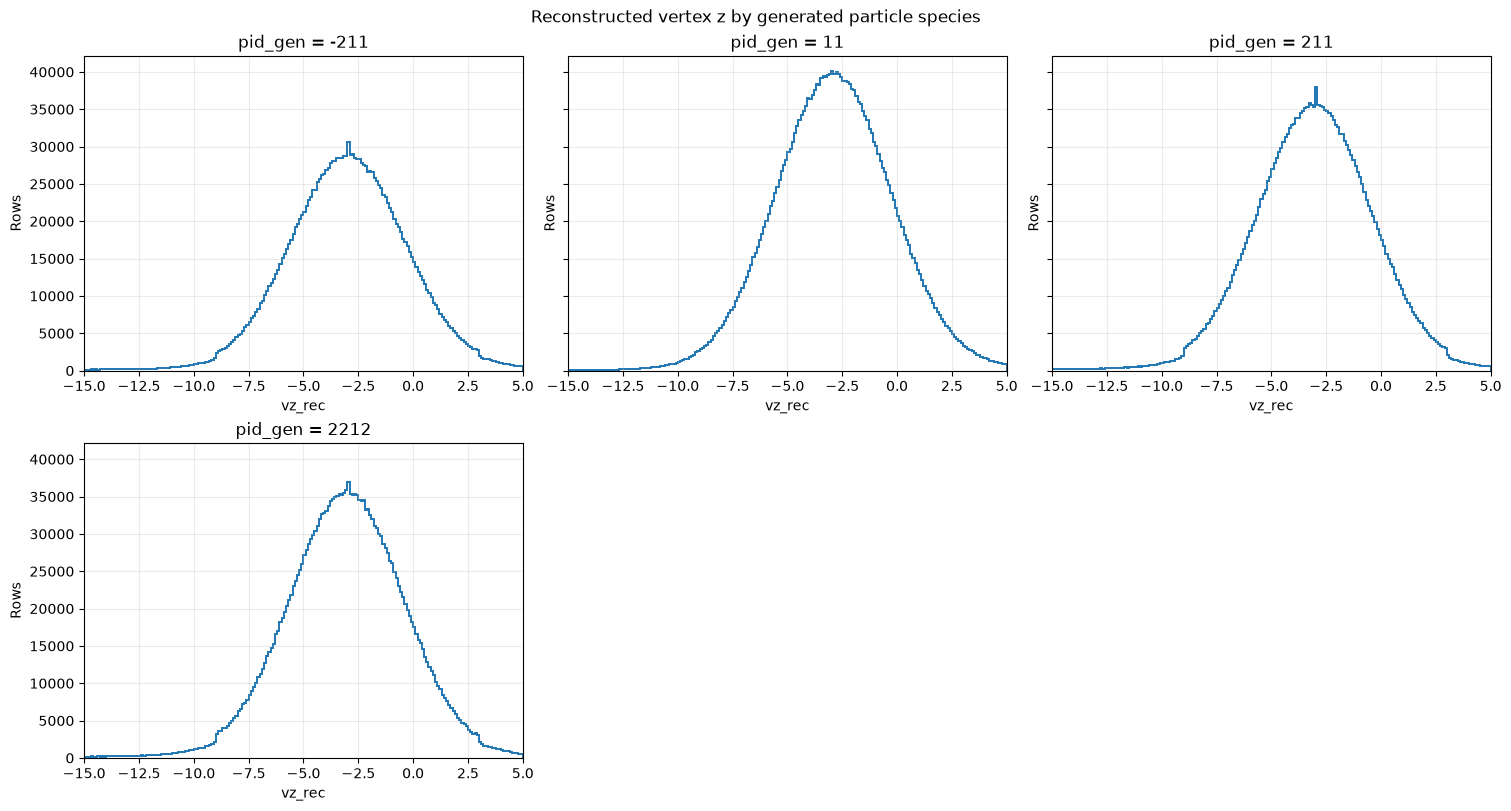

In [9]:
# Plot reconstructed-vertex z within the global electron-trigger event selection.
VZ_PLOT_COLUMNS = ["pid_gen", "vz_rec"]
VZ_PLOT_BINS = np.linspace(-15.0, 5.0, 201)
VZ_PLOT_TICKS = np.arange(-15.0, 5.1, 2.5)
VZ_PLOT_COUNTS = {}

for record_batch in parquet_dataset.scanner(
    columns=VZ_PLOT_COLUMNS,
    filter=GLOBAL_EVENT_CUT,
    batch_size=250_000,
    use_threads=True,
    batch_readahead=2,
    fragment_readahead=1,
 ).to_batches():
    batch_df = record_batch.to_pandas()
    batch_df = batch_df.dropna(subset=VZ_PLOT_COLUMNS)
    batch_df = batch_df[np.isfinite(batch_df["vz_rec"])]
    for pid, species_df in batch_df.groupby("pid_gen", sort=False):
        histogram, _ = np.histogram(species_df["vz_rec"], bins=VZ_PLOT_BINS)
        VZ_PLOT_COUNTS[pid] = VZ_PLOT_COUNTS.get(pid, 0) + histogram

species_pids = sorted(VZ_PLOT_COUNTS)
panel_columns = 3
panel_rows = int(np.ceil(len(species_pids) / panel_columns))
figure, axes = plt.subplots(
    panel_rows,
    panel_columns,
    figsize=(15, 4 * panel_rows),
    sharex=True,
    sharey=True,
    squeeze=False,
    constrained_layout=True,
 )

for axis, pid in zip(axes.flat, species_pids):
    axis.stairs(VZ_PLOT_COUNTS[pid], VZ_PLOT_BINS, color="tab:blue", linewidth=1.4)
    axis.set_title(f"pid_gen = {pid:g}")
    axis.set_xlabel("vz_rec")
    axis.set_ylabel("Rows")
    axis.set_xlim(VZ_PLOT_BINS[0], VZ_PLOT_BINS[-1])
    axis.set_xticks(VZ_PLOT_TICKS)
    axis.tick_params(axis="x", labelbottom=True)
    axis.grid(alpha=0.25)

for axis in axes.flat[len(species_pids):]:
    axis.set_visible(False)

figure.suptitle("Reconstructed vertex z by generated particle species")
plt.show()

In [10]:
# Add row-level reconstruction, vertex, and electron-momentum cuts.
VZ_REC_MIN = -5.5
VZ_REC_MAX = -0.5
ELECTRON_REC_P_MIN = 2.0
RECONSTRUCTED_CUT = ds.field("reconstructed") == 1
VZ_REC_CUT = (ds.field("vz_rec") > VZ_REC_MIN) & (ds.field("vz_rec") < VZ_REC_MAX)
EVENT_RECONSTRUCTED_CUT = GLOBAL_EVENT_CUT & RECONSTRUCTED_CUT
RECONSTRUCTED_VZ_CUT = EVENT_RECONSTRUCTED_CUT & VZ_REC_CUT
REC_ELECTRON_MOMENTUM_CUT = (
    (ds.field("pid_gen") != 11)
    | (ds.field("p_rec") > ELECTRON_REC_P_MIN)
)
GLOBAL_CUT = RECONSTRUCTED_VZ_CUT & REC_ELECTRON_MOMENTUM_CUT

reconstructed_rows = parquet_dataset.count_rows(filter=EVENT_RECONSTRUCTED_CUT)
reconstructed_vz_rows = parquet_dataset.count_rows(filter=RECONSTRUCTED_VZ_CUT)
global_cut_rows = parquet_dataset.count_rows(filter=GLOBAL_CUT)
removed_without_reco = global_event_rows - reconstructed_rows
removed_by_vz_cut = reconstructed_rows - reconstructed_vz_rows
removed_by_electron_momentum_cut = reconstructed_vz_rows - global_cut_rows

# Count rows passing GLOBAL_CUT for each generated particle species.
PARTICLE_NAMES_BY_PID = {
    11: "electron (e-)",
    -211: "pi-",
    211: "pi+",
    2212: "proton",
}
def count_rows_by_generated_pid(row_filter):
    rows_by_pid = {}
    for record_batch in parquet_dataset.scanner(
        columns=["pid_gen"],
        filter=row_filter,
        batch_size=250_000,
    ).to_batches():
        batch_pids, batch_counts = np.unique(
            record_batch.column(0).to_numpy(zero_copy_only=False),
            return_counts=True,
        )
        for pid, count in zip(batch_pids, batch_counts):
            pid = int(pid)
            rows_by_pid[pid] = rows_by_pid.get(pid, 0) + int(count)

    return pd.DataFrame(
        [
            {
                "pid_gen": pid,
                "particle": PARTICLE_NAMES_BY_PID.get(pid, f"PDG {pid}"),
                "rows": rows,
            }
            for pid, rows in sorted(rows_by_pid.items())
        ]
    )

particle_row_counts = count_rows_by_generated_pid(GLOBAL_CUT)
assert particle_row_counts["rows"].sum() == global_cut_rows

FORWARD_DETECTOR_CUT = ds.field("detector") == 1
FD_GLOBAL_CUT = GLOBAL_CUT & FORWARD_DETECTOR_CUT
fd_particle_row_counts = count_rows_by_generated_pid(FD_GLOBAL_CUT)
fd_rows = int(fd_particle_row_counts["rows"].sum())
assert fd_rows == parquet_dataset.count_rows(filter=FD_GLOBAL_CUT)

print(f"Rows after global electron-trigger event cut: {global_event_rows:,}")
print(f"Rows with reconstructed partner: {reconstructed_rows:,}")
print(f"Removed without reconstructed partner: {removed_without_reco:,}")
print(f"Rows passing reconstructed partner and vz_rec cut: {reconstructed_vz_rows:,}")
print(f"Removed by vz_rec cut: {removed_by_vz_cut:,}")
print(f"Rows passing all row-level cuts: {global_cut_rows:,}")
print(f"Electron rows removed by p_rec cut: {removed_by_electron_momentum_cut:,}")
print(f"Rows removed after event-level cut: {global_event_rows - global_cut_rows:,}")
print(f"Vertex cut: {VZ_REC_MIN} < vz_rec < {VZ_REC_MAX}")
print(f"Electron momentum cut: p_rec > {ELECTRON_REC_P_MIN} GeV for pid_gen == 11")
print("\nRows passing GLOBAL_CUT by generated particle:")
print(
    particle_row_counts.to_string(
        index=False,
        formatters={"rows": "{:,}".format},
    )
)
print(f"\nRows in the forward detector after GLOBAL_CUT: {fd_rows:,}")
print(
    fd_particle_row_counts.to_string(
        index=False,
        formatters={"rows": "{:,}".format},
    )
)

Rows after global electron-trigger event cut: 10,599,780
Rows with reconstructed partner: 9,349,688
Removed without reconstructed partner: 1,250,092
Rows passing reconstructed partner and vz_rec cut: 6,042,494
Removed by vz_rec cut: 3,307,194
Rows passing all row-level cuts: 5,981,615
Electron rows removed by p_rec cut: 60,879
Rows removed after event-level cut: 4,618,165
Vertex cut: -5.5 < vz_rec < -0.5
Electron momentum cut: p_rec > 2.0 GeV for pid_gen == 11

Rows passing GLOBAL_CUT by generated particle:
 pid_gen      particle      rows
    -211           pi- 1,247,135
      11 electron (e-) 1,660,817
     211           pi+ 1,537,032
    2212        proton 1,536,631

Rows in the forward detector after GLOBAL_CUT: 3,496,420
 pid_gen      particle      rows
    -211           pi-   579,324
      11 electron (e-) 1,660,817
     211           pi+   639,286
    2212        proton   616,993


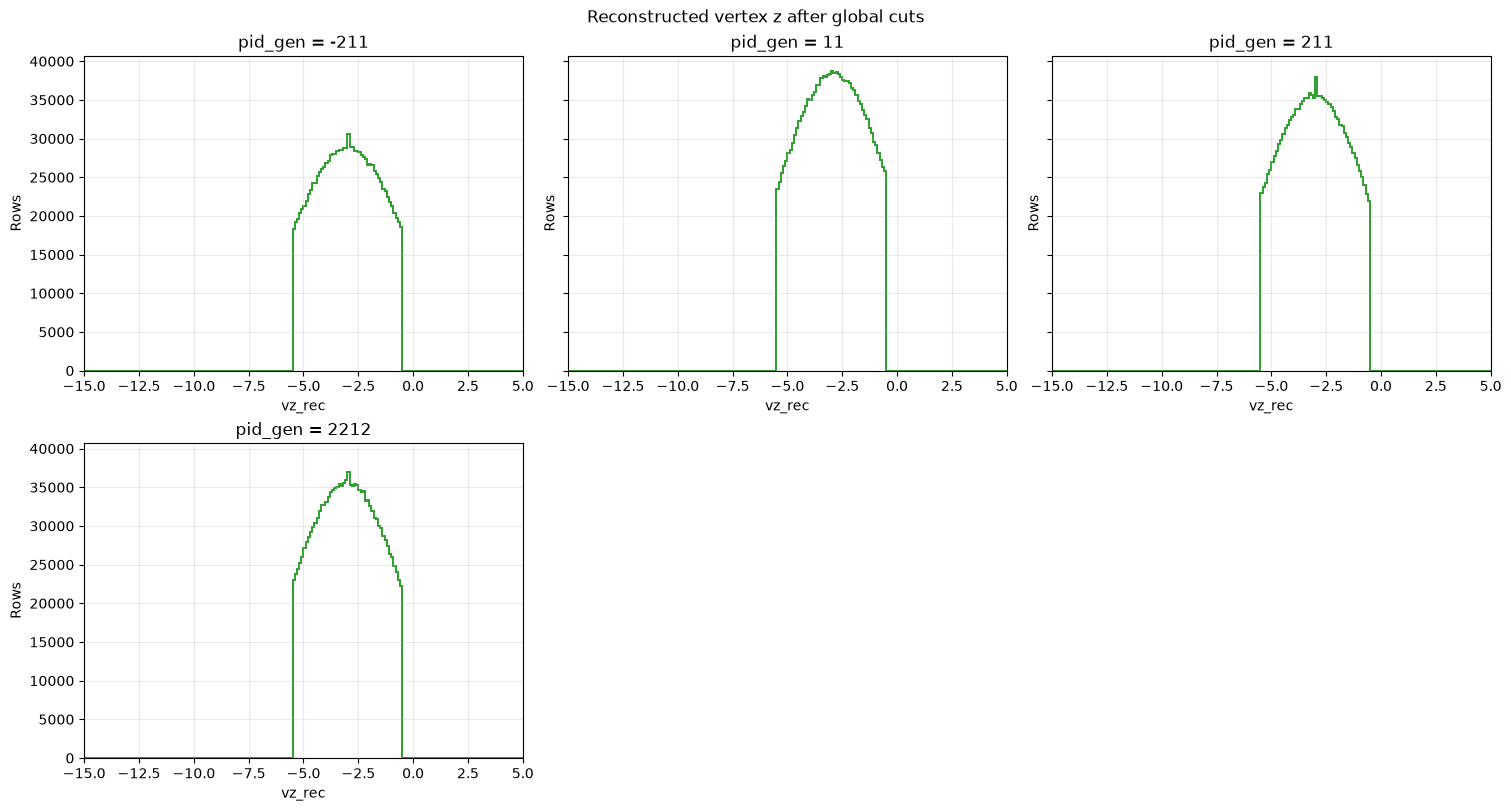

In [11]:
# Plot vz_rec distributions after applying the global dataset cuts.
VZ_POSTCUT_COUNTS = {}

for record_batch in parquet_dataset.scanner(
    columns=VZ_PLOT_COLUMNS,
    filter=GLOBAL_CUT,
    batch_size=250_000,
    use_threads=True,
    batch_readahead=2,
    fragment_readahead=1,
 ).to_batches():
    batch_df = record_batch.to_pandas()
    batch_df = batch_df.dropna(subset=VZ_PLOT_COLUMNS)
    batch_df = batch_df[np.isfinite(batch_df["vz_rec"])]
    for pid, species_df in batch_df.groupby("pid_gen", sort=False):
        histogram, _ = np.histogram(species_df["vz_rec"], bins=VZ_PLOT_BINS)
        VZ_POSTCUT_COUNTS[pid] = VZ_POSTCUT_COUNTS.get(pid, 0) + histogram

postcut_species_pids = sorted(VZ_POSTCUT_COUNTS)
figure, axes = plt.subplots(
    panel_rows,
    panel_columns,
    figsize=(15, 4 * panel_rows),
    sharex=True,
    sharey=True,
    squeeze=False,
    constrained_layout=True,
 )

for axis, pid in zip(axes.flat, postcut_species_pids):
    axis.stairs(VZ_POSTCUT_COUNTS[pid], VZ_PLOT_BINS, color="tab:green", linewidth=1.4)
    axis.set_title(f"pid_gen = {pid:g}")
    axis.set_xlabel("vz_rec")
    axis.set_ylabel("Rows")
    axis.set_xlim(VZ_PLOT_BINS[0], VZ_PLOT_BINS[-1])
    axis.set_xticks(VZ_PLOT_TICKS)
    axis.tick_params(axis="x", labelbottom=True)
    axis.grid(alpha=0.25)

for axis in axes.flat[len(postcut_species_pids):]:
    axis.set_visible(False)

figure.suptitle("Reconstructed vertex z after global cuts")
plt.show()

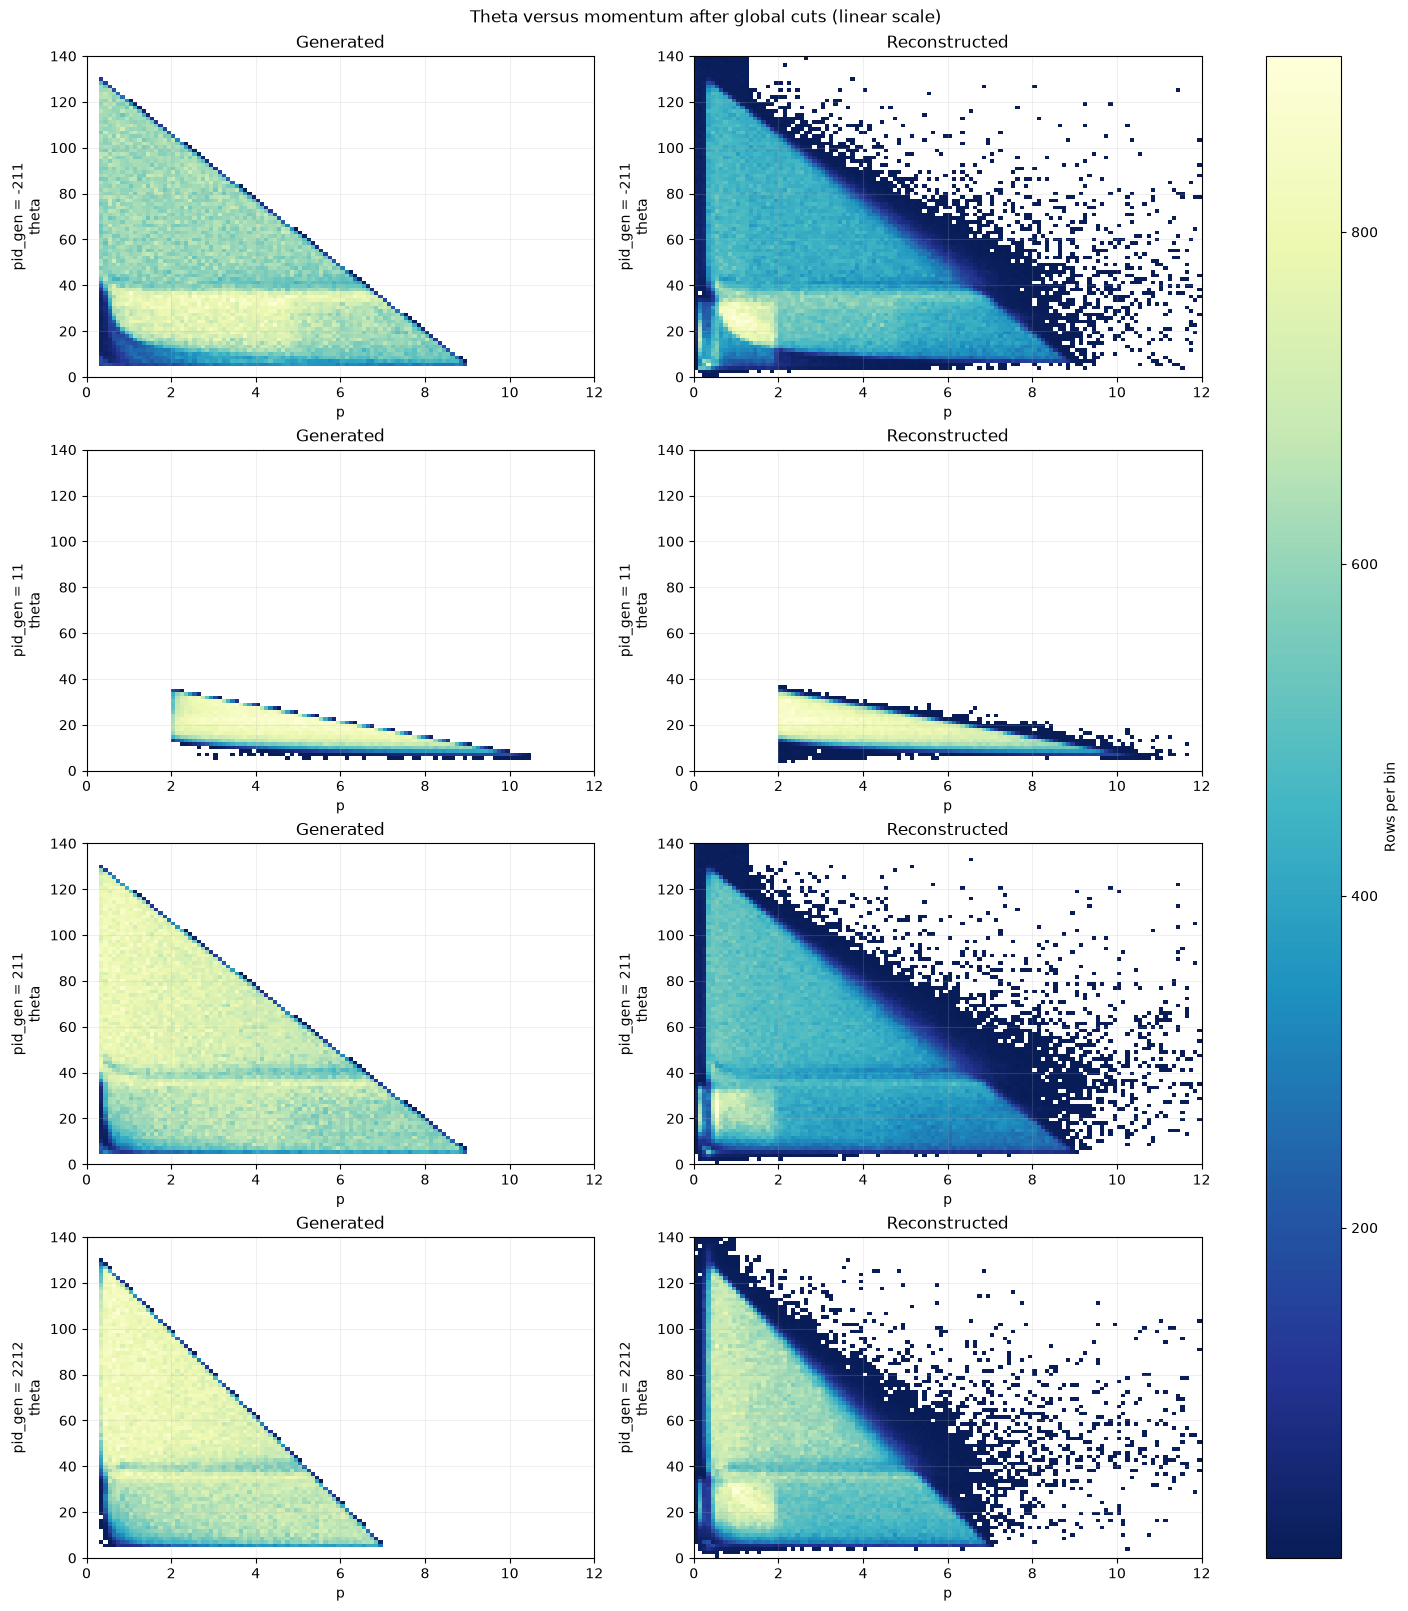

In [12]:
# Compare generated and reconstructed theta versus p after all global cuts.
PLOT2D_COLUMNS = ["pid_gen", "p_gen", "theta_gen", "p_rec", "theta_rec"]
PLOT2D_PAIRS = [("p_gen", "theta_gen"), ("p_rec", "theta_rec")]
PLOT2D_BINS = {
    "p_gen": np.linspace(0.0, 12.0, 121),
    "theta_gen": np.linspace(0.0, 140.0 , 91),
    "p_rec": np.linspace(0.0, 12.0, 121),
    "theta_rec": np.linspace(0.0, 140.0, 91),
}
PLOT2D_TICKS = np.arange(0.0, 12.1, 2.0)
PLOT2D_COUNTS = {
    (pid, x_name, y_name): np.zeros(
        (len(PLOT2D_BINS[y_name]) - 1, len(PLOT2D_BINS[x_name]) - 1),
        dtype=np.int64,
    )
    for pid in species_pids
    for x_name, y_name in PLOT2D_PAIRS
}

for record_batch in parquet_dataset.scanner(
    columns=PLOT2D_COLUMNS,
    filter=GLOBAL_CUT,
    batch_size=250_000,
    use_threads=True,
    batch_readahead=2,
    fragment_readahead=1,
 ).to_batches():
    batch_df = record_batch.to_pandas()
    for pid, species_df in batch_df.groupby("pid_gen", sort=False):
        for x_name, y_name in PLOT2D_PAIRS:
            valid = (
                np.isfinite(species_df[x_name])
                & np.isfinite(species_df[y_name])
            )
            histogram, _, _ = np.histogram2d(
                species_df.loc[valid, y_name],
                species_df.loc[valid, x_name],
                bins=[PLOT2D_BINS[y_name], PLOT2D_BINS[x_name]],
            )
            PLOT2D_COUNTS[(pid, x_name, y_name)] += histogram.astype(np.int64)

plot2d_rows = len(species_pids)
figure, axes = plt.subplots(
    plot2d_rows,
    2,
    figsize=(14, 4 * plot2d_rows),
    sharex="col",
    sharey="col",
    squeeze=False,
    constrained_layout=True,
 )
plot_cmap = plt.colormaps["YlGnBu_r"].with_extremes(bad="white")

for row, pid in enumerate(species_pids):
    for column, (x_name, y_name) in enumerate(PLOT2D_PAIRS):
        axis = axes[row, column]
        counts = PLOT2D_COUNTS[(pid, x_name, y_name)]
        image = axis.pcolormesh(
            PLOT2D_BINS[x_name],
            PLOT2D_BINS[y_name],
            np.ma.masked_less(counts, 1),
            shading="auto",
            cmap=plot_cmap,
        )
        axis.set_title("Generated" if column == 0 else "Reconstructed")
        axis.set_xlabel("p")
        axis.set_ylabel(f"pid_gen = {pid:g}\ntheta")
        axis.set_xlim(0.0, 12.0)
        axis.set_xticks(PLOT2D_TICKS)
        axis.tick_params(axis="x", labelbottom=True)
        axis.grid(alpha=0.2)

figure.colorbar(image, ax=axes.ravel().tolist(), label="Rows per bin")
figure.suptitle("Theta versus momentum after global cuts (linear scale)")
plt.show()

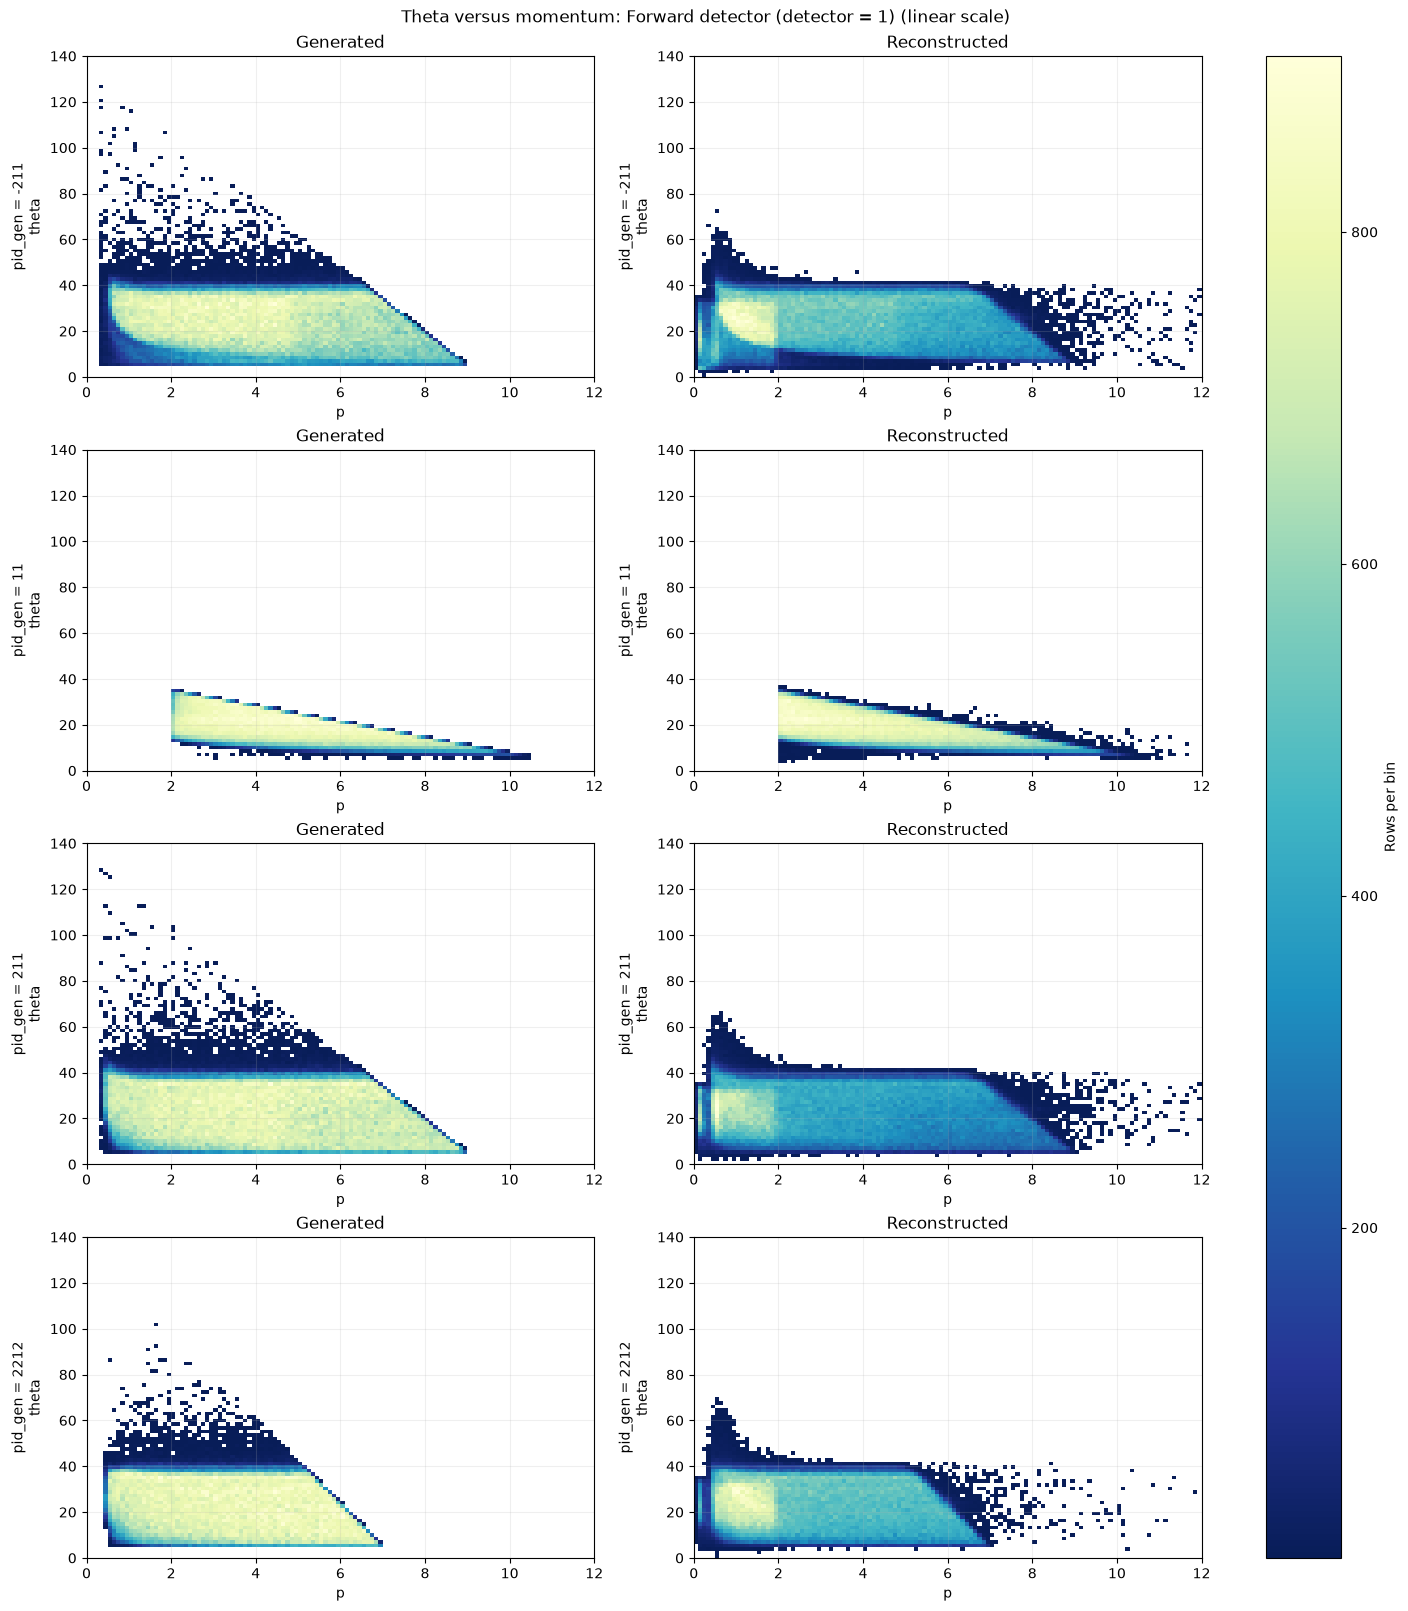

In [13]:
# Forward detector: compare generated and reconstructed theta versus p.
#DETECTOR_FILTER = (GLOBAL_CUT & (ds.field("detector") == 1) & (ds.field("pid_gen") == ds.field("pid_rec"))) # PID_rec = PID_gen
DETECTOR_FILTER = GLOBAL_CUT & (ds.field("detector") == 1)  # NO PID_rec = PID_gen
DETECTOR_NAME = "Forward detector (detector = 1)"
DETECTOR_PLOT_COUNTS = {
    (pid, x_name, y_name): np.zeros(
        (len(PLOT2D_BINS[y_name]) - 1, len(PLOT2D_BINS[x_name]) - 1),
        dtype=np.int64,
    )
    for pid in species_pids
    for x_name, y_name in PLOT2D_PAIRS
}

for record_batch in parquet_dataset.scanner(
    columns=PLOT2D_COLUMNS,
    filter=DETECTOR_FILTER,
    batch_size=250_000,
    use_threads=True,
    batch_readahead=2,
    fragment_readahead=1,
 ).to_batches():
    batch_df = record_batch.to_pandas()
    for pid, species_df in batch_df.groupby("pid_gen", sort=False):
        for x_name, y_name in PLOT2D_PAIRS:
            valid = (
                np.isfinite(species_df[x_name])
                & np.isfinite(species_df[y_name])
            )
            histogram, _, _ = np.histogram2d(
                species_df.loc[valid, y_name],
                species_df.loc[valid, x_name],
                bins=[PLOT2D_BINS[y_name], PLOT2D_BINS[x_name]],
            )
            DETECTOR_PLOT_COUNTS[(pid, x_name, y_name)] += histogram.astype(np.int64)

figure, axes = plt.subplots(
    len(species_pids),
    2,
    figsize=(14, 4 * len(species_pids)),
    sharex="col",
    sharey="col",
    squeeze=False,
    constrained_layout=True,
 )
plot_cmap = plt.colormaps["YlGnBu_r"].with_extremes(bad="white")

for row, pid in enumerate(species_pids):
    for column, (x_name, y_name) in enumerate(PLOT2D_PAIRS):
        axis = axes[row, column]
        counts = DETECTOR_PLOT_COUNTS[(pid, x_name, y_name)]
        image = axis.pcolormesh(
            PLOT2D_BINS[x_name],
            PLOT2D_BINS[y_name],
            np.ma.masked_less(counts, 1),
            shading="auto",
            cmap=plot_cmap,
        )
        axis.set_title("Generated" if column == 0 else "Reconstructed")
        axis.set_xlabel("p")
        axis.set_ylabel(f"pid_gen = {pid:g}\ntheta")
        axis.set_xlim(0.0, 12.0)
        axis.set_xticks(PLOT2D_TICKS)
        axis.tick_params(axis="x", labelbottom=True)
        axis.grid(alpha=0.2)

figure.colorbar(image, ax=axes.ravel().tolist(), label="Rows per bin")
figure.suptitle(f"Theta versus momentum: {DETECTOR_NAME} (linear scale)")
plt.show()

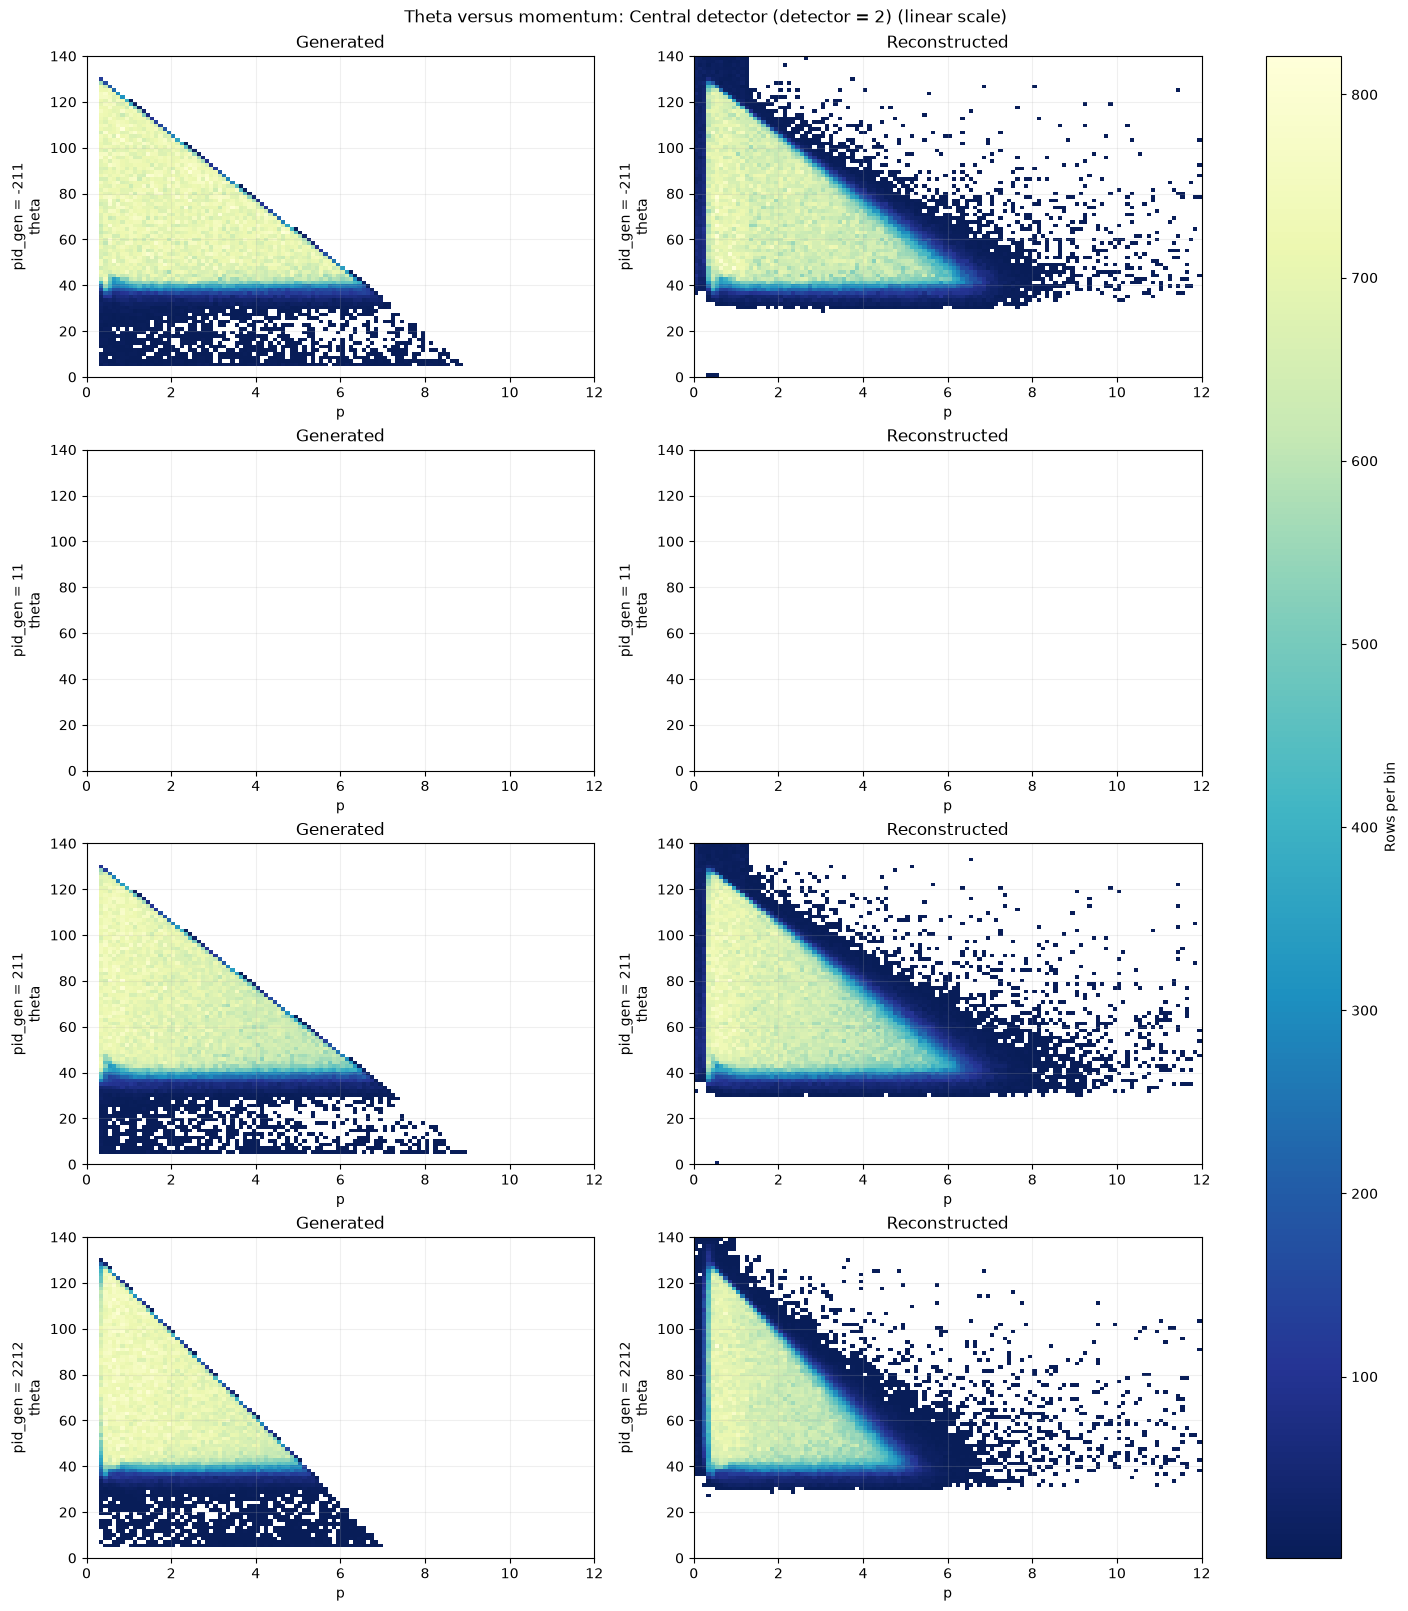

In [14]:
# Central detector: compare generated and reconstructed theta versus p.
#DETECTOR_FILTER = (GLOBAL_CUT & (ds.field("detector") == 2) & (ds.field("pid_gen") == ds.field("pid_rec")))  # PID_rec = PID_gen
DETECTOR_FILTER = GLOBAL_CUT & (ds.field("detector") == 2)   # NO PID_rec = PID_gen
DETECTOR_NAME = "Central detector (detector = 2)"
DETECTOR_PLOT_COUNTS = {
    (pid, x_name, y_name): np.zeros(
        (len(PLOT2D_BINS[y_name]) - 1, len(PLOT2D_BINS[x_name]) - 1),
        dtype=np.int64,
    )
    for pid in species_pids
    for x_name, y_name in PLOT2D_PAIRS
}

for record_batch in parquet_dataset.scanner(
    columns=PLOT2D_COLUMNS,
    filter=DETECTOR_FILTER,
    batch_size=250_000,
    use_threads=True,
    batch_readahead=2,
    fragment_readahead=1,
 ).to_batches():
    batch_df = record_batch.to_pandas()
    for pid, species_df in batch_df.groupby("pid_gen", sort=False):
        for x_name, y_name in PLOT2D_PAIRS:
            valid = (
                np.isfinite(species_df[x_name])
                & np.isfinite(species_df[y_name])
            )
            histogram, _, _ = np.histogram2d(
                species_df.loc[valid, y_name],
                species_df.loc[valid, x_name],
                bins=[PLOT2D_BINS[y_name], PLOT2D_BINS[x_name]],
            )
            DETECTOR_PLOT_COUNTS[(pid, x_name, y_name)] += histogram.astype(np.int64)

figure, axes = plt.subplots(
    len(species_pids),
    2,
    figsize=(14, 4 * len(species_pids)),
    sharex="col",
    sharey="col",
    squeeze=False,
    constrained_layout=True,
 )
plot_cmap = plt.colormaps["YlGnBu_r"].with_extremes(bad="white")

for row, pid in enumerate(species_pids):
    for column, (x_name, y_name) in enumerate(PLOT2D_PAIRS):
        axis = axes[row, column]
        counts = DETECTOR_PLOT_COUNTS[(pid, x_name, y_name)]
        image = axis.pcolormesh(
            PLOT2D_BINS[x_name],
            PLOT2D_BINS[y_name],
            np.ma.masked_less(counts, 1),
            shading="auto",
            cmap=plot_cmap,
        )
        axis.set_title("Generated" if column == 0 else "Reconstructed")
        axis.set_xlabel("p")
        axis.set_ylabel(f"pid_gen = {pid:g}\ntheta")
        axis.set_xlim(0.0, 12.0)
        axis.set_xticks(PLOT2D_TICKS)
        axis.tick_params(axis="x", labelbottom=True)
        axis.grid(alpha=0.2)

figure.colorbar(image, ax=axes.ravel().tolist(), label="Rows per bin")
figure.suptitle(f"Theta versus momentum: {DETECTOR_NAME} (linear scale)")
plt.show()

In [15]:
# Selecting only FD reconstructed events
FORWARD_DETECTOR_CUT = ds.field("detector") == 1
OPTIONAL_CUTS = (ds.field("pid_gen")== ds.field("pid_rec")) & (ds.field("delta_theta") < 2) & (ds.field("delta_phi") < 2) 
GLOBAL_CUT = GLOBAL_CUT & FORWARD_DETECTOR_CUT 


reconstructed_rows = parquet_dataset.count_rows(filter=EVENT_RECONSTRUCTED_CUT)
global_cut_rows = parquet_dataset.count_rows(filter=GLOBAL_CUT)


print(f"Rows after global electron-trigger event cut: {global_event_rows:,}")
print(f"Rows with reconstructed partner: {reconstructed_rows:,}")
print(f"Removed without reconstructed partner: {removed_without_reco:,}")
print(f"Rows passing reconstructed partner, vz_rec cut and FD: {global_cut_rows:,}")


Rows after global electron-trigger event cut: 10,599,780
Rows with reconstructed partner: 9,349,688
Removed without reconstructed partner: 1,250,092
Rows passing reconstructed partner, vz_rec cut and FD: 3,496,420


In [16]:
DELTA_P_CUT = (ds.field("delta_p") < 0.15) & ((ds.field("delta_p") > -0.15))
GLOBAL_CUT = GLOBAL_CUT & DELTA_P_CUT

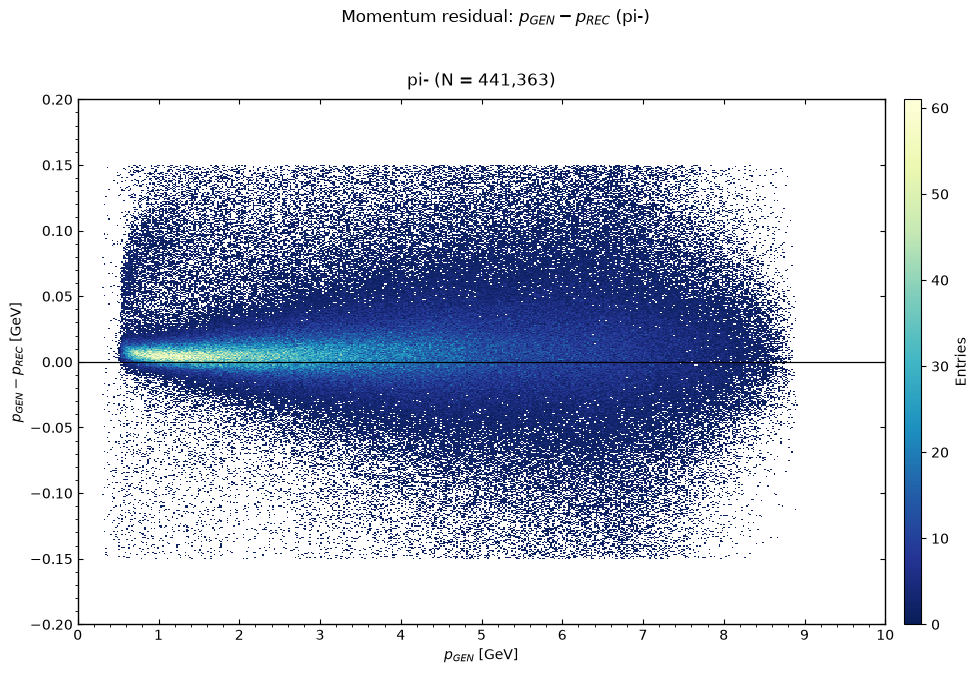

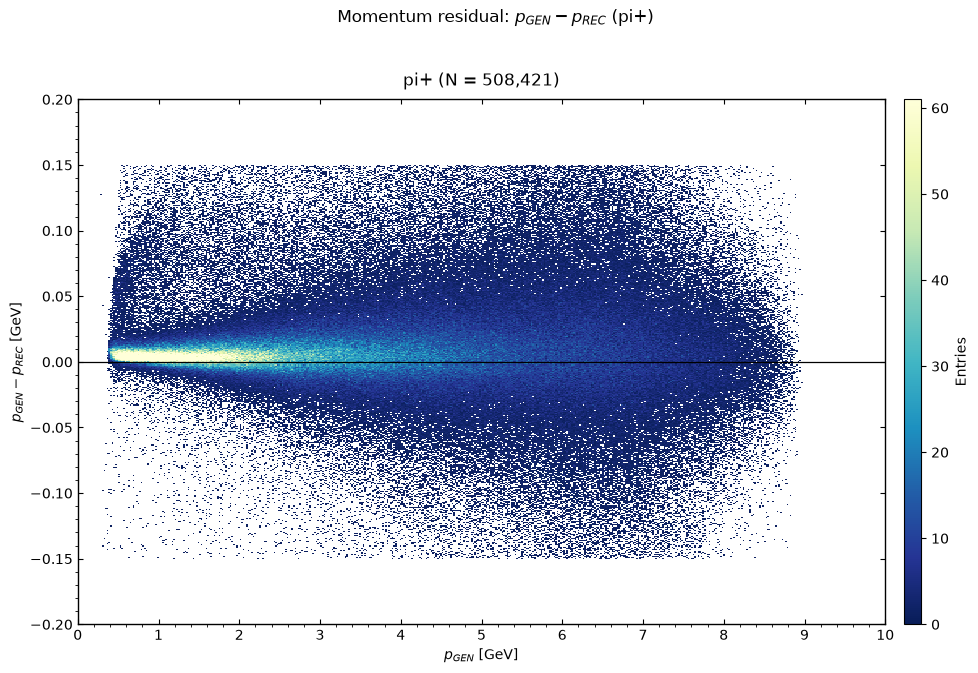

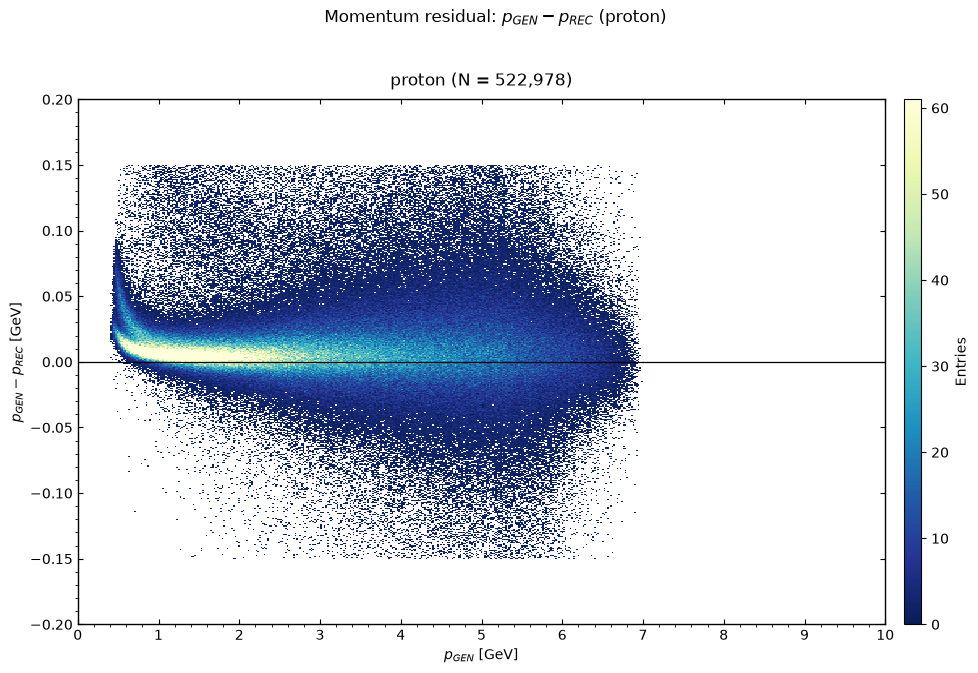

In [17]:
# Delta p versus generated momentum for all hadron rows after global cuts.
HADRON_PIDS = {
    -211: "pi-",
    211: "pi+",
    2212: "proton",
}
DELTAP_COLUMNS = ["pid_gen", "p_gen", "p_rec"]
DELTAP_X_BINS = np.linspace(0.0, 10.0, 500)
DELTAP_Y_LIMITS = (-0.2, 0.2)
DELTAP_Y_BINS = np.linspace(*DELTAP_Y_LIMITS, 500)
DELTAP_Y_TICKS = np.arange(-0.2, 0.201, 0.05)
DELTAP_COUNTS = {
    pid: np.zeros(
        (len(DELTAP_Y_BINS) - 1, len(DELTAP_X_BINS) - 1),
        dtype=np.int64,
    )
    for pid in HADRON_PIDS
}
DELTAP_EVENT_COUNTS = {pid: 0 for pid in HADRON_PIDS}
HADRON_FILTER = GLOBAL_CUT & ds.field("pid_gen").isin(list(HADRON_PIDS))

for record_batch in parquet_dataset.scanner(
    columns=DELTAP_COLUMNS,
    filter=HADRON_FILTER,
    batch_size=250_000,
    use_threads=True,
    batch_readahead=2,
    fragment_readahead=1,
 ).to_batches():
    batch_df = record_batch.to_pandas()
    valid = (
        batch_df["pid_gen"].isin(HADRON_PIDS)
        & np.isfinite(batch_df["p_gen"])
        & np.isfinite(batch_df["p_rec"])
    )
    batch_df = batch_df.loc[valid].copy()
    batch_df["delta_p_plot"] = np.clip(
        batch_df["p_gen"] - batch_df["p_rec"],
        DELTAP_Y_LIMITS[0],
        DELTAP_Y_LIMITS[1],
    )
    for pid in HADRON_PIDS:
        species_df = batch_df[batch_df["pid_gen"] == pid]
        DELTAP_EVENT_COUNTS[pid] += len(species_df)
        histogram, _, _ = np.histogram2d(
            species_df["delta_p_plot"],
            species_df["p_gen"],
            bins=[DELTAP_Y_BINS, DELTAP_X_BINS],
        )
        DELTAP_COUNTS[pid] += histogram.astype(np.int64)

positive_counts = np.concatenate([counts[counts > 0] for counts in DELTAP_COUNTS.values()])
colorbar_max = max(1, np.percentile(positive_counts, 99.5))
plot_cmap = plt.colormaps["YlGnBu_r"].with_extremes(bad="white")

for pid, particle_name in HADRON_PIDS.items():
    figure, axis = plt.subplots(
        1,
        1,
        figsize=(9.5, 7.5),
        facecolor="white",
    )
    image = axis.pcolormesh(
        DELTAP_X_BINS,
        DELTAP_Y_BINS,
        np.ma.masked_less(DELTAP_COUNTS[pid], 1),
        shading="auto",
        cmap=plot_cmap,
        vmin=0,
        vmax=colorbar_max,
    )
    axis.axhline(0.0, color="black", linewidth=0.9)
    axis.set_title(f"{particle_name} (N = {DELTAP_EVENT_COUNTS[pid]:,})", pad=10)
    axis.set_xlabel(r"$p_{GEN}$ [GeV]")
    axis.set_ylabel(r"$p_{GEN} - p_{REC}$ [GeV]")
    axis.set_xlim(0.0, 10.0)
    axis.set_ylim(*DELTAP_Y_LIMITS)
    axis.set_xticks(np.arange(0.0, 10.1, 1.0))
    axis.set_yticks(DELTAP_Y_TICKS)
    axis.tick_params(axis="both", direction="in", top=True, right=True, labelleft=True)
    axis.minorticks_on()
    axis.grid(False)
    for spine in axis.spines.values():
        spine.set_linewidth(1.0)

    figure.subplots_adjust(left=0.06, right=0.91, bottom=0.14, top=0.84)
    colorbar_axis = figure.add_axes([0.93, 0.14, 0.018, 0.70])
    figure.colorbar(image, cax=colorbar_axis, label="Entries")
    figure.suptitle(rf"Momentum residual: $p_{{GEN}} - p_{{REC}}$ ({particle_name})", y=0.96)
    figure.patch.set_facecolor("white")
    plt.show()

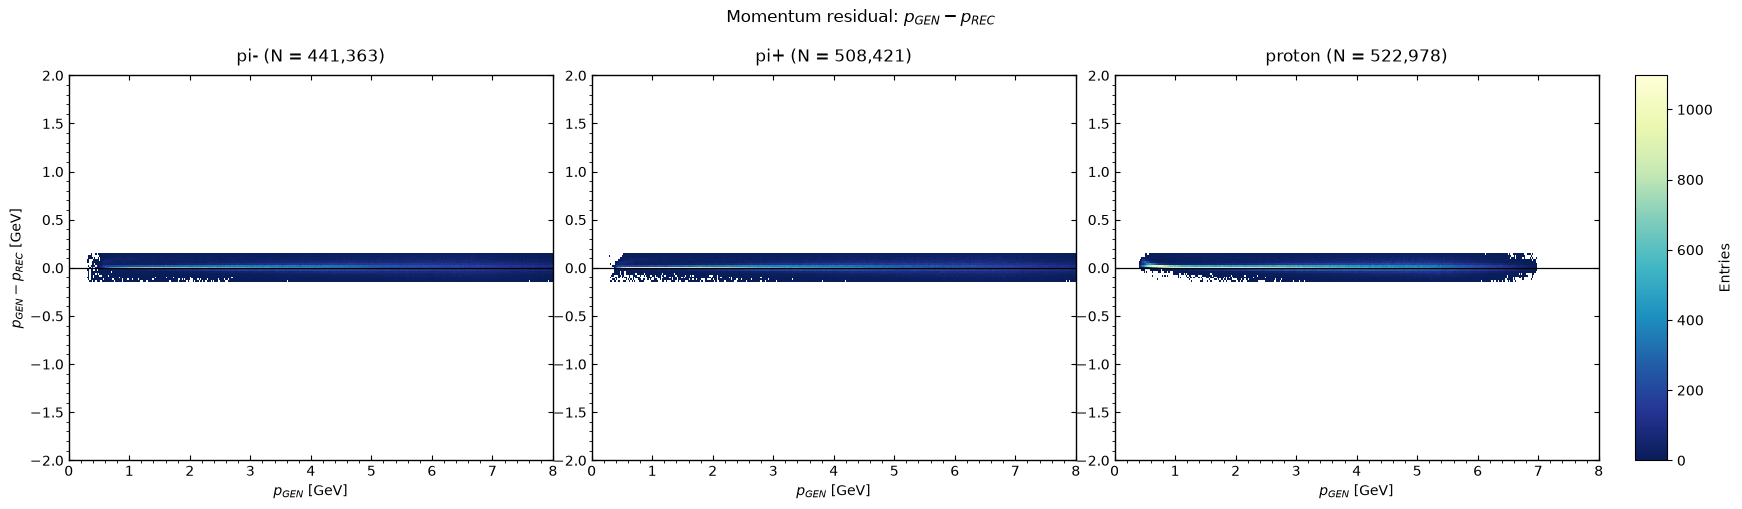

In [18]:
# Delta p versus generated momentum for all hadron rows after global cuts.
HADRON_PIDS = {
    -211: "pi-",
    211: "pi+",
    2212: "proton",
}
DELTAP_COLUMNS = ["pid_gen", "p_gen", "p_rec"]
DELTAP_X_BINS = np.linspace(0.0, 8.0, 400)
DELTAP_Y_LIMITS = (-2, 2)
DELTAP_Y_BINS = np.linspace(*DELTAP_Y_LIMITS, 200)
DELTAP_Y_TICKS = np.arange(-2, 2.01, 0.5)
DELTAP_COUNTS = {
    pid: np.zeros(
        (len(DELTAP_Y_BINS) - 1, len(DELTAP_X_BINS) - 1),
        dtype=np.int64,
    )
    for pid in HADRON_PIDS
}
DELTAP_EVENT_COUNTS = {pid: 0 for pid in HADRON_PIDS}
HADRON_FILTER = GLOBAL_CUT & ds.field("pid_gen").isin(list(HADRON_PIDS))

for record_batch in parquet_dataset.scanner(
    columns=DELTAP_COLUMNS,
    filter=HADRON_FILTER,
    batch_size=250_000,
    use_threads=True,
    batch_readahead=2,
    fragment_readahead=1,
 ).to_batches():
    batch_df = record_batch.to_pandas()
    valid = (
        batch_df["pid_gen"].isin(HADRON_PIDS)
        & np.isfinite(batch_df["p_gen"])
        & np.isfinite(batch_df["p_rec"])
    )
    batch_df = batch_df.loc[valid].copy()
    batch_df["delta_p_plot"] = np.clip(
        batch_df["p_gen"] - batch_df["p_rec"],
        DELTAP_Y_LIMITS[0],
        DELTAP_Y_LIMITS[1],
    )
    for pid in HADRON_PIDS:
        species_df = batch_df[batch_df["pid_gen"] == pid]
        DELTAP_EVENT_COUNTS[pid] += len(species_df)
        histogram, _, _ = np.histogram2d(
            species_df["delta_p_plot"],
            species_df["p_gen"],
            bins=[DELTAP_Y_BINS, DELTAP_X_BINS],
        )
        DELTAP_COUNTS[pid] += histogram.astype(np.int64)

figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
    sharex=True,
    sharey=True,
    squeeze=False,
    facecolor="white",
 )
axes = axes.ravel()
positive_counts = np.concatenate([counts[counts > 0] for counts in DELTAP_COUNTS.values()])
colorbar_max = max(1, np.percentile(positive_counts, 99.5))
plot_cmap = plt.colormaps["YlGnBu_r"].with_extremes(bad="white")

for axis, (pid, particle_name) in zip(axes, HADRON_PIDS.items()):
    image = axis.pcolormesh(
        DELTAP_X_BINS,
        DELTAP_Y_BINS,
        np.ma.masked_less(DELTAP_COUNTS[pid], 1),
        shading="auto",
        cmap=plot_cmap,
        vmin=0,
        vmax=colorbar_max,
    )
    axis.axhline(0.0, color="black", linewidth=0.9)
    axis.set_title(f"{particle_name} (N = {DELTAP_EVENT_COUNTS[pid]:,})", pad=10)
    axis.set_xlabel(r"$p_{GEN}$ [GeV]")
    axis.set_ylabel(r"$p_{GEN} - p_{REC}$ [GeV]" if axis is axes[0] else "")
    axis.set_xlim(0.0, 8.0)
    axis.set_ylim(*DELTAP_Y_LIMITS)
    axis.set_xticks(np.arange(0.0, 8.1, 1.0))
    axis.set_yticks(DELTAP_Y_TICKS)
    axis.tick_params(axis="both", direction="in", top=True, right=True, labelleft=True)
    axis.minorticks_on()
    axis.grid(False)
    for spine in axis.spines.values():
        spine.set_linewidth(1.0)

figure.subplots_adjust(left=0.06, right=0.91, bottom=0.14, top=0.84, wspace=0.08)
colorbar_axis = figure.add_axes([0.93, 0.14, 0.018, 0.70])
figure.colorbar(image, cax=colorbar_axis, label="Entries")
figure.suptitle(r"Momentum residual: $p_{GEN} - p_{REC}$", y=0.96)
figure.patch.set_facecolor("white")
plt.show()

In [19]:
# Select proton rows after the existing global, FD, and delta-p cuts.
PROTON_PID = 2212
PROTON_CUT = GLOBAL_CUT & (ds.field("pid_gen") == PROTON_PID)
df_proton = parquet_dataset.to_table(
    columns=["p_rec", "theta_rec", "phi_rec", "delta_p"],
    filter=PROTON_CUT,
).to_pandas()

# Inputs: reconstructed kinematics
# Target: delta_p = p_gen - p_rec
n_sample_proton = len(df_proton)
df_proton_ml = df_proton.sample(n=n_sample_proton, random_state=42).copy()

X_proton = df_proton_ml[["p_rec", "theta_rec", "phi_rec"]].copy()
y_proton = df_proton_ml["delta_p"].copy()

print("Proton rows selected:", f"{n_sample_proton:,}")
print("df_proton_ml shape:", df_proton_ml.shape)
print("X_proton shape:", X_proton.shape)
print("y_proton shape:", y_proton.shape)
print()
print(X_proton.head())
print()
print("Target is delta_p = p_gen - p_rec")

Proton rows selected: 522,978
df_proton_ml shape: (522978, 4)
X_proton shape: (522978, 3)
y_proton shape: (522978,)

           p_rec  theta_rec     phi_rec
199362  6.446378  12.518103 -106.584396
257773  1.106570  27.255274  104.292984
407735  3.135001  34.183826 -137.308441
520899  1.131716   5.996281  -73.008835
414673  5.165621   8.434785 -106.951736

Target is delta_p = p_gen - p_rec


In [20]:
from sklearn.model_selection import train_test_split

X_train_proton, X_test_proton, y_train_proton, y_test_proton = train_test_split(
    X_proton,
    y_proton,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train_proton.shape)
print("X_test shape :", X_test_proton.shape)
print("y_train shape:", y_train_proton.shape)
print("y_test shape :", y_test_proton.shape)

X_train shape: (418382, 3)
X_test shape : (104596, 3)
y_train shape: (418382,)
y_test shape : (104596,)


In [21]:
import xgboost
from xgboost import XGBRegressor

print(xgboost.__version__)

proton_params = dict(
    objective="reg:absoluteerror",
    tree_method="hist",
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=2,
    min_child_weight=50,
    gamma=1e-4,
    reg_lambda=10.0,
    subsample=0.9,
    colsample_bytree=1.0,
    random_state=42,
)

xgb_proton = XGBRegressor(**proton_params)
xgb_proton.fit(X_train_proton, y_train_proton)

3.2.0


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [22]:
tree_df = xgb_proton.get_booster().trees_to_dataframe()

n_trees = tree_df["Tree"].nunique()
n_splits = int((tree_df["Feature"] != "Leaf").sum())
n_leaves = int((tree_df["Feature"] == "Leaf").sum())

train_pred = xgb_proton.predict(X_train_proton)
test_pred = xgb_proton.predict(X_test_proton)

print("Trees:", n_trees)
print("Split nodes:", n_splits)
print("Leaf nodes:", n_leaves)
print()
print("Rows per tree:")
print(tree_df.groupby("Tree").size().describe())
print()
print("y_train std:", np.std(y_train_proton))
print("train prediction std:", np.std(train_pred))
print("test prediction std:", np.std(test_pred))

Trees: 1000
Split nodes: 3000
Leaf nodes: 4000

Rows per tree:
count    1000.0
mean        7.0
std         0.0
min         7.0
25%         7.0
50%         7.0
75%         7.0
max         7.0
dtype: float64

y_train std: 0.034402102
train prediction std: 0.012422351
test prediction std: 0.0125876255


In [23]:
# Predict delta_p:
#     delta_p = p_gen - p_rec

delta_p_pred_proton = xgb_proton.predict(X_test_proton)
delta_p_true_proton = y_test_proton.to_numpy()

# Residual of the predicted delta-p correction:
#     predicted delta_p - true delta_p
delta_p_residual_proton = delta_p_pred_proton - delta_p_true_proton

print("delta_p_pred_proton shape:", delta_p_pred_proton.shape)
print("delta_p_true_proton shape:", delta_p_true_proton.shape)
print()

print("Delta-p_proton prediction residual: delta_p_pred - delta_p_true")
print(f"Mean = {np.mean(delta_p_residual_proton):.6f} GeV")
print(f"Std  = {np.std(delta_p_residual_proton):.6f} GeV")
print(f"MAE  = {np.mean(np.abs(delta_p_residual_proton)):.6f} GeV")

delta_p_pred_proton shape: (104596,)
delta_p_true_proton shape: (104596,)

Delta-p_proton prediction residual: delta_p_pred - delta_p_true
Mean = -0.000990 GeV
Std  = 0.031993 GeV
MAE  = 0.020134 GeV


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(delta_p_true_proton, delta_p_pred_proton)
rmse = np.sqrt(mse)
mae = mean_absolute_error(delta_p_true_proton, delta_p_pred_proton)
r2 = r2_score(delta_p_true_proton, delta_p_pred_proton)

print("Delta-p MSE :", mse)
print("Delta-p RMSE:", rmse)
print("Delta-p MAE :", mae)
print("Delta-p R^2 :", r2)

Delta-p MSE : 0.0010245030280202627
Delta-p RMSE: 0.03200785884779334
Delta-p MAE : 0.02013370208442211
Delta-p R^2 : 0.13860464096069336


Raw momentum residual:       p_rec - p_gen
  mean = -0.010135 GeV
  std  = 0.034487 GeV
  MAE  = 0.023370 GeV

Predicted momentum residual: p_pred - p_gen
  mean = -0.000990 GeV
  std  = 0.031993 GeV
  MAE  = 0.020134 GeV


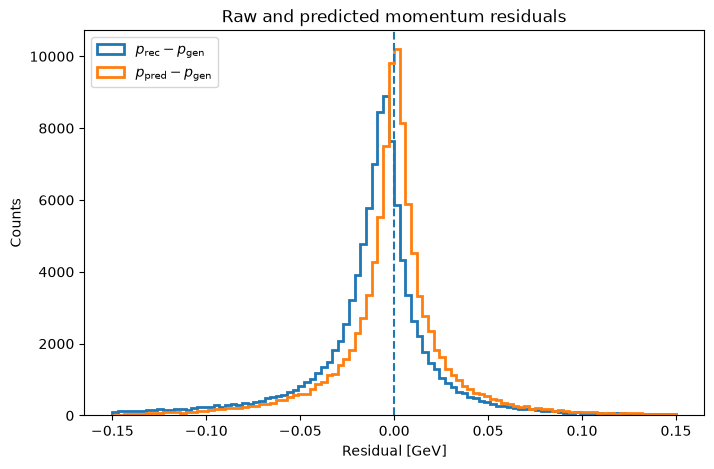

In [25]:
# -------------------------------------------------------------------
# Reconstruct predicted generated momentum from the predicted delta-p:
#
#     delta_p = p_gen - p_rec
#
# Therefore:
#
#     p_pred = p_rec + delta_p_pred
# -------------------------------------------------------------------

p_rec_test = X_test_proton["p_rec"].to_numpy()

p_gen_true = p_rec_test + delta_p_true_proton
p_pred     = p_rec_test + delta_p_pred_proton

# Use the same residual convention in every notebook:
#
#     raw residual   = p_rec  - p_gen
#     model residual = p_pred - p_gen

rec_minus_gen  = p_rec_test - p_gen_true
pred_minus_gen = p_pred - p_gen_true

mean_raw = np.mean(rec_minus_gen)
std_raw  = np.std(rec_minus_gen)
mae_raw  = np.mean(np.abs(rec_minus_gen))

mean_pred = np.mean(pred_minus_gen)
std_pred  = np.std(pred_minus_gen)
mae_pred  = np.mean(np.abs(pred_minus_gen))

print("Raw momentum residual:       p_rec - p_gen")
print(f"  mean = {mean_raw:.6f} GeV")
print(f"  std  = {std_raw:.6f} GeV")
print(f"  MAE  = {mae_raw:.6f} GeV")
print()

print("Predicted momentum residual: p_pred - p_gen")
print(f"  mean = {mean_pred:.6f} GeV")
print(f"  std  = {std_pred:.6f} GeV")
print(f"  MAE  = {mae_pred:.6f} GeV")




# -------------------------------------------------------------------
# 3. Compare raw and predicted residual distributions
# -------------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    rec_minus_gen,
    bins=100,
    range=[-0.15, 0.15],
    histtype="step",
    linewidth=2,
    label=rf"$p_{{\mathrm{{rec}}}} - p_{{\mathrm{{gen}}}}$"

)

plt.hist(
    pred_minus_gen,
    bins=100,
    range=[-0.15, 0.15],
    histtype="step",
    linewidth=2,
    label=rf"$p_{{\mathrm{{pred}}}} - p_{{\mathrm{{gen}}}}$"

)

plt.xlabel("Residual [GeV]")
plt.ylabel("Counts")
plt.title("Raw and predicted momentum residuals")

plt.axvline(0, linestyle="--")
plt.legend(loc="upper left")
plt.show()

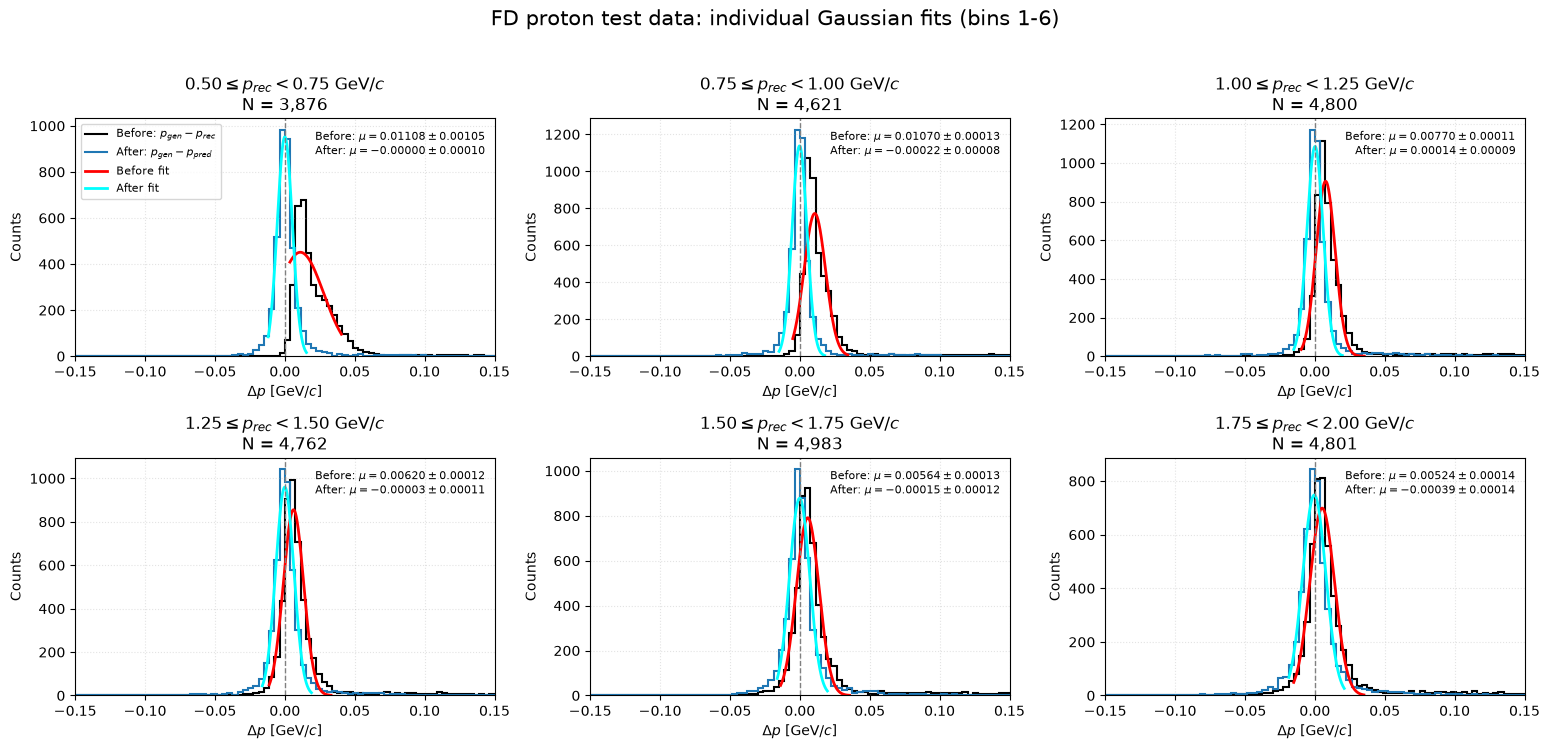

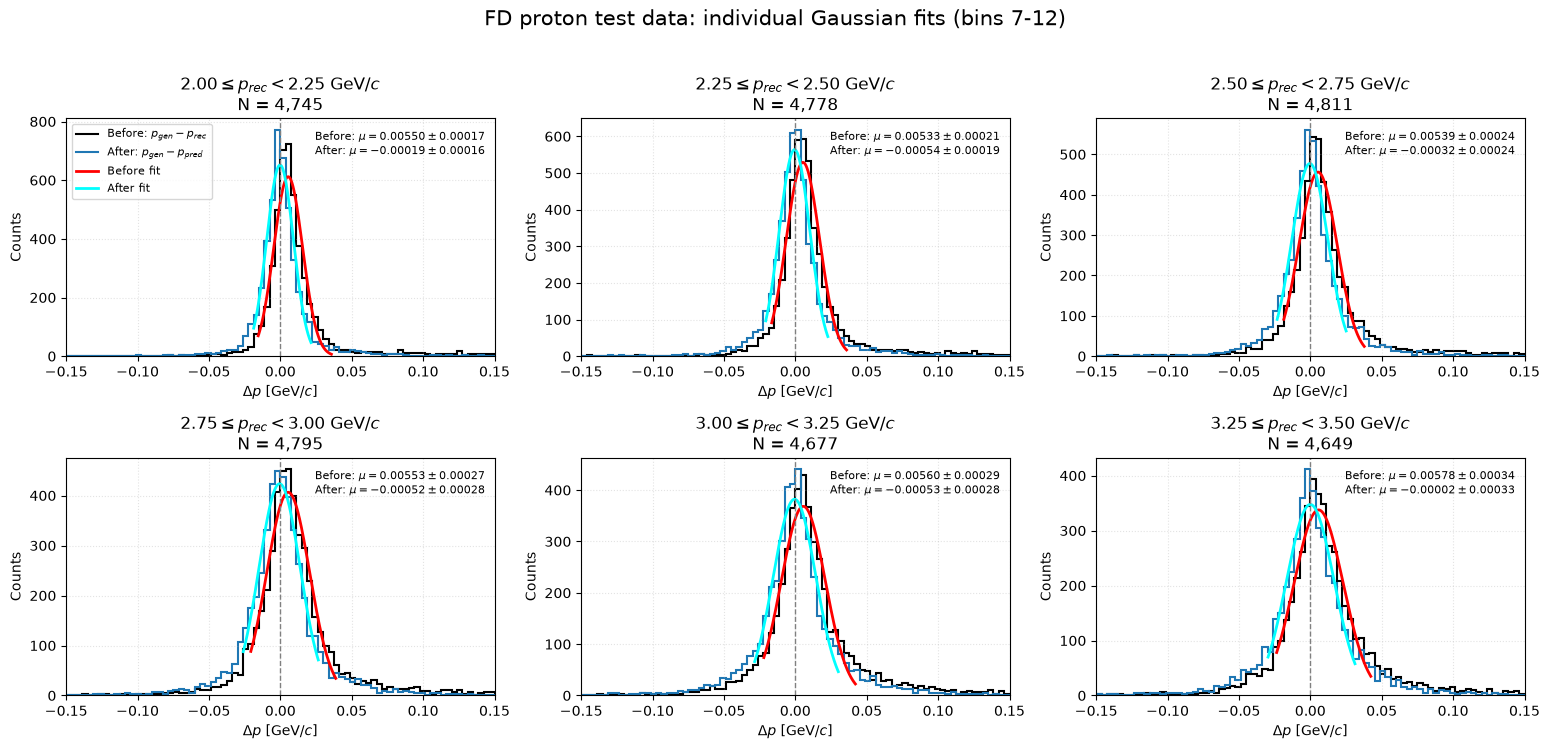

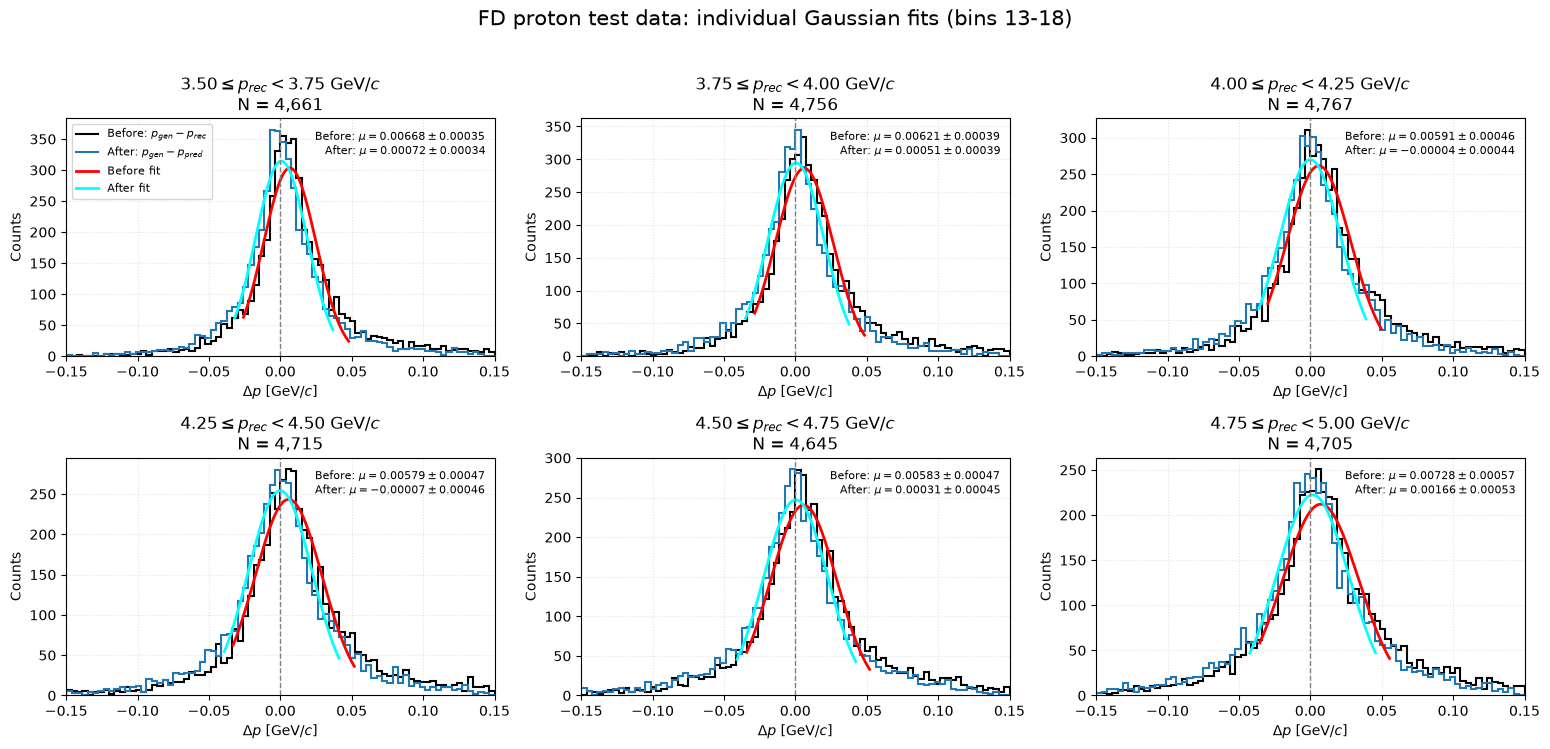

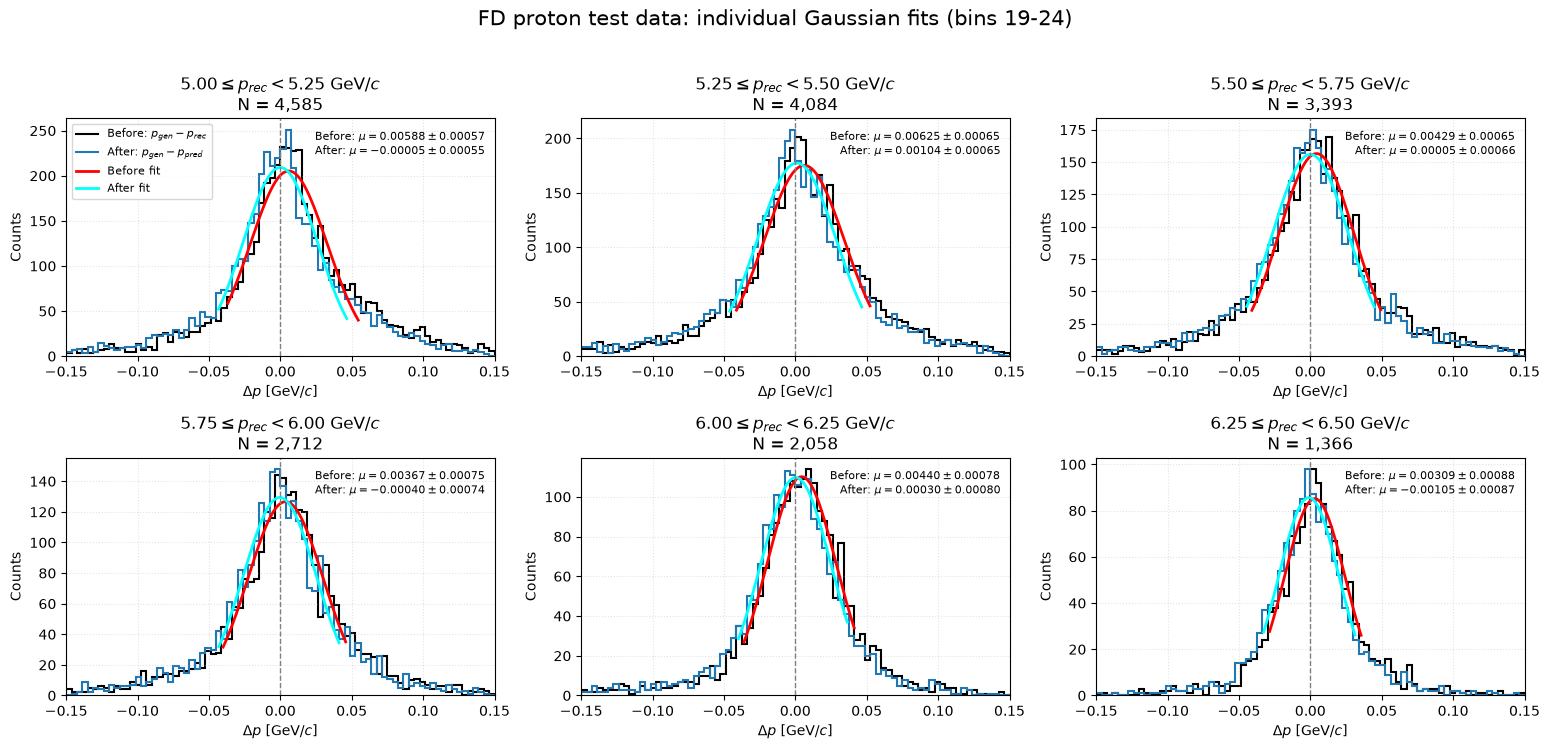

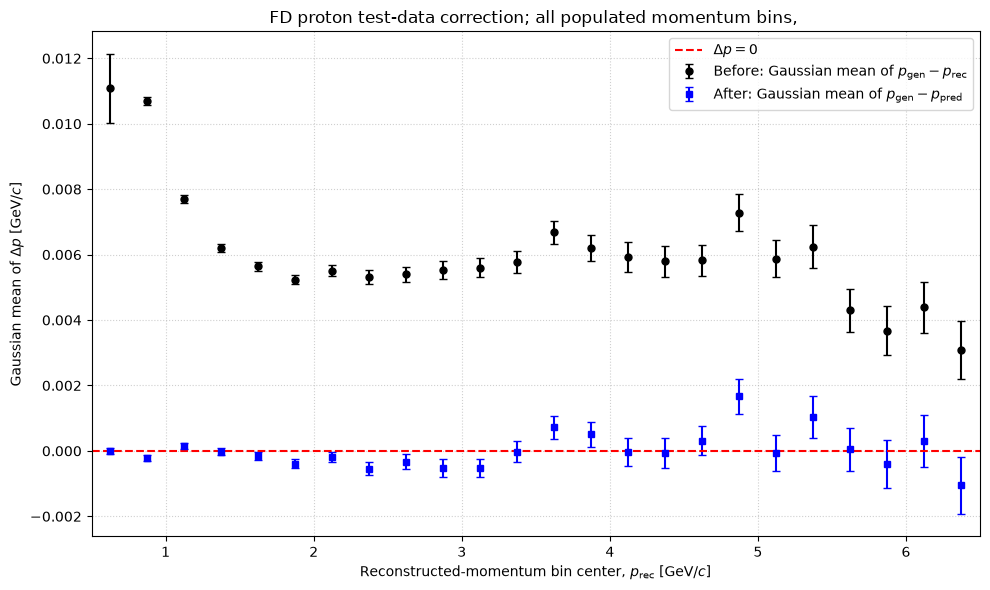

In [26]:
from scipy.optimize import curve_fit
from scipy.stats import norm
import warnings


# ------------------------------------------------------------
# Test data, one combined theta acceptance
# ------------------------------------------------------------

p_rec_test = X_test_proton["p_rec"].to_numpy()
theta_rec_test = X_test_proton["theta_rec"].to_numpy()

delta_p_before_test = delta_p_true_proton

# p_pred = p_rec + delta_p_pred
# p_gen - p_pred = delta_p_true - delta_p_pred
delta_p_after_test = (
    delta_p_true_proton - delta_p_pred_proton
)



MOMENTUM_BIN_WIDTH = 0.25
MOMENTUM_MAX = 6.5

# Start from the lowest populated physical momentum.
accepted_momenta = p_rec_test[

     np.isfinite(p_rec_test)
    & (p_rec_test >= 0.0)
    & (p_rec_test < MOMENTUM_MAX)
]

momentum_min = 0.5  # GeV/c

momentum_edges = np.arange(
    momentum_min,
    MOMENTUM_MAX + 0.5 * MOMENTUM_BIN_WIDTH,
    MOMENTUM_BIN_WIDTH,
)

RESIDUAL_LIMITS = (-0.15, 0.15)
RESIDUAL_HIST_BINS = 160
GAUSSIAN_PEAK_NSIGMA = 1.0


def gaussian_no_rejection(x, amplitude, mean, sigma):
    return amplitude * np.exp(
        -0.5 * ((x - mean) / sigma) ** 2
    )


def fit_gaussian_peak_one_sigma(values, rebin_factor=2):
    """
    Fit only the central peak of every populated momentum bin.

    The peak window is defined from the histogram entries as
    preliminary mean +/- one preliminary standard deviation.
    Only histogram bins inside that window enter the Gaussian fit.
    rebin_factor=2 merges every two adjacent residual bins
    before the fit, matching ROOT's Rebin(2) behavior.
    """

    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return None

    # Build the displayed histogram in the standard residual range.
    histogram_values = values[
        (values >= RESIDUAL_LIMITS[0])
        & (values <= RESIDUAL_LIMITS[1])
    ]

    # Pathological fallback when fewer than three entries are inside
    # the standard residual range. No populated momentum bin is dropped.
    if histogram_values.size < 3:
        histogram_values = values
        histogram_low = float(values.min())
        histogram_high = float(values.max())

        if histogram_high <= histogram_low:
            histogram_low -= 0.001
            histogram_high += 0.001
    else:
        histogram_low = RESIDUAL_LIMITS[0]
        histogram_high = RESIDUAL_LIMITS[1]

    counts, edges = np.histogram(
        histogram_values,
        bins=RESIDUAL_HIST_BINS,
        range=(histogram_low, histogram_high),
    )

    rebin_factor = int(rebin_factor)

    if rebin_factor < 1:
        raise ValueError("rebin_factor must be at least 1")

    if counts.size % rebin_factor != 0:
        raise ValueError(
            "RESIDUAL_HIST_BINS must be divisible by rebin_factor"
        )

    if rebin_factor > 1:
        counts = counts.reshape(-1, rebin_factor).sum(axis=1)
        edges = edges[::rebin_factor]

    centers = 0.5 * (edges[:-1] + edges[1:])
    histogram_bin_width = edges[1] - edges[0]

    preliminary_mean = float(np.mean(histogram_values))
    preliminary_sigma = float(np.std(histogram_values, ddof=1))

    if not np.isfinite(preliminary_sigma) or preliminary_sigma <= 0:
        preliminary_sigma = histogram_bin_width

    fit_low = max(
        histogram_low,
        preliminary_mean
        - GAUSSIAN_PEAK_NSIGMA * preliminary_sigma,
    )

    fit_high = min(
        histogram_high,
        preliminary_mean
        + GAUSSIAN_PEAK_NSIGMA * preliminary_sigma,
    )

    peak_values = histogram_values[
        (histogram_values >= fit_low)
        & (histogram_values <= fit_high)
    ]

    fit_mask = (
        (centers >= fit_low)
        & (centers <= fit_high)
    )

    fit_method = "binned Gaussian fit in mean +/- 1 sigma"

    try:
        if np.count_nonzero(fit_mask) < 4 or peak_values.size < 3:
            raise RuntimeError("Too few points in the one-sigma peak window")

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            parameters, covariance = curve_fit(
                gaussian_no_rejection,
                centers[fit_mask],
                counts[fit_mask],
                p0=(
                    counts.max(),
                    preliminary_mean,
                    preliminary_sigma,
                ),
                sigma=np.sqrt(
                    np.maximum(counts[fit_mask], 1.0)
                ),
                absolute_sigma=True,
                bounds=(
                    (
                        0.0,
                        histogram_low,
                        0.1 * histogram_bin_width,
                    ),
                    (
                        np.inf,
                        histogram_high,
                        histogram_high - histogram_low,
                    ),
                ),
                maxfev=50_000,
            )

        parameter_errors = np.sqrt(
            np.diag(covariance)
        )

        amplitude, mean, sigma = parameters
        _, mean_error, sigma_error = parameter_errors

        if not np.all(
            np.isfinite(
                [
                    amplitude,
                    mean,
                    sigma,
                    mean_error,
                    sigma_error,
                ]
            )
        ):
            raise RuntimeError(
                "Non-finite binned-fit result"
            )

    except Exception:
        # Preserve populated bins if the binned optimizer cannot fit the
        # peak. This fallback still uses only entries in the one-sigma window.
        fallback_values = peak_values if peak_values.size >= 2 else histogram_values
        mean, sigma = norm.fit(fallback_values)

        sigma = max(
            float(sigma),
            histogram_bin_width,
        )

        amplitude = (
            len(fallback_values)
            * histogram_bin_width
            / (np.sqrt(2.0 * np.pi) * sigma)
        )

        mean_error = sigma / np.sqrt(
            len(fallback_values)
        )

        sigma_error = sigma / np.sqrt(
            max(2 * (len(fallback_values) - 1), 1)
        )

        parameters = np.array(
            [amplitude, mean, sigma]
        )

        fit_method = "unbinned Gaussian MLE in mean +/- 1 sigma"

    observed = counts[fit_mask]

    fitted = gaussian_no_rejection(
        centers[fit_mask],
        *parameters,
    )

    residual_sum_squares = np.sum(
        (observed - fitted) ** 2
    )

    total_sum_squares = np.sum(
        (observed - observed.mean()) ** 2
    )

    fit_r2 = (
        1.0
        - residual_sum_squares / total_sum_squares
        if total_sum_squares > 0
        else np.nan
    )

    return {
        "counts": counts,
        "edges": edges,
        "parameters": parameters,
        "mean": mean,
        "mean_error": mean_error,
        "sigma": sigma,
        "sigma_error": sigma_error,
        "r2": fit_r2,
        "fit_low": fit_low,
        "fit_high": fit_high,
        "entries": len(values),
        "entries_in_fit_range": len(peak_values),
        "preliminary_mean": preliminary_mean,
        "preliminary_sigma": preliminary_sigma,
        "rebin_factor": rebin_factor,
        "method": fit_method,
    }


# ------------------------------------------------------------
# Fit every populated momentum bin
# ------------------------------------------------------------

momentum_fit_details_test = []
momentum_fit_records_test = []

for p_low, p_high in zip(
    momentum_edges[:-1],
    momentum_edges[1:],
):
    panel_mask = (
        (p_rec_test >= p_low)
        & (p_rec_test < p_high)
    )

    panel_entries = int(
        np.count_nonzero(panel_mask)
    )

    # An empty bin physically cannot be fitted.
    if panel_entries == 0:
        print(
            f"Empty momentum bin: "
            f"{p_low:.2f}-{p_high:.2f} GeV/c"
        )
        continue

    before_fit = fit_gaussian_peak_one_sigma(
        delta_p_before_test[panel_mask]
    )

    after_fit = fit_gaussian_peak_one_sigma(
        delta_p_after_test[panel_mask]
    )

    if before_fit is None or after_fit is None:
        raise RuntimeError(
            f"Could not fit populated momentum bin "
            f"{p_low:.2f}-{p_high:.2f} GeV/c"
        )

    momentum_fit_details_test.append(
        {
            "p_low": p_low,
            "p_high": p_high,
            "entries": panel_entries,
            "before": before_fit,
            "after": after_fit,
        }
    )

    momentum_fit_records_test.append(
        {
            "p_low": p_low,
            "p_high": p_high,
            "p_center": 0.5 * (p_low + p_high),
            "entries": panel_entries,

            "before_mean": before_fit["mean"],
            "before_mean_error":
                before_fit["mean_error"],
            "before_sigma": before_fit["sigma"],
            "before_r2": before_fit["r2"],
            "before_method": before_fit["method"],

            "after_mean": after_fit["mean"],
            "after_mean_error":
                after_fit["mean_error"],
            "after_sigma": after_fit["sigma"],
            "after_r2": after_fit["r2"],
            "after_method": after_fit["method"],
        }
    )

gaussian_mean_vs_momentum_test_all_bins = (
    pd.DataFrame(momentum_fit_records_test)
)

# ------------------------------------------------------------
# Inspect every individual fitted momentum bin
# ------------------------------------------------------------

FITS_PER_FIGURE = 6

for page_start in range(0, len(momentum_fit_details_test), FITS_PER_FIGURE):
    page_details = momentum_fit_details_test[
        page_start:page_start + FITS_PER_FIGURE
    ]
    ncols = 3
    nrows = int(np.ceil(len(page_details) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5.2 * ncols, 3.8 * nrows),
        squeeze=False,
    )
    axes = axes.ravel()

    for panel_index, fit_data in enumerate(page_details):
        ax = axes[panel_index]
        before_fit = fit_data["before"]
        after_fit = fit_data["after"]

        ax.stairs(
            before_fit["counts"],
            before_fit["edges"],
            color="black",
            linewidth=1.5,
            label=r"Before: $p_{gen}-p_{rec}$",
        )
        ax.stairs(
            after_fit["counts"],
            after_fit["edges"],
            color="tab:blue",
            linewidth=1.5,
            label=r"After: $p_{gen}-p_{pred}$",
        )

        before_x = np.linspace(before_fit["fit_low"], before_fit["fit_high"], 400)
        after_x = np.linspace(after_fit["fit_low"], after_fit["fit_high"], 400)
        ax.plot(
            before_x,
            gaussian_no_rejection(before_x, *before_fit["parameters"]),
            color="red",
            linewidth=2.0,
            label="Before fit",
        )
        ax.plot(
            after_x,
            gaussian_no_rejection(after_x, *after_fit["parameters"]),
            color="cyan",
            linewidth=2.0,
            label="After fit",
        )

        ax.axvline(0.0, color="gray", linestyle="--", linewidth=1.0)
        ax.set_xlim(RESIDUAL_LIMITS)
        ax.set_xlabel(r"$\Delta p$ [GeV/$c$]")
        ax.set_ylabel("Counts")
        ax.set_title(
            rf"${fit_data['p_low']:.2f} \leq p_{{rec}} < {fit_data['p_high']:.2f}$ GeV/$c$"
            f"\nN = {fit_data['entries']:,}"
        )
        ax.grid(True, linestyle=":", alpha=0.35)

        fit_text = (
            rf"Before: $\mu={before_fit['mean']:.5f} \pm {before_fit['mean_error']:.5f}$"
            "\n"
            rf"After: $\mu={after_fit['mean']:.5f} \pm {after_fit['mean_error']:.5f}$"
        )
        ax.text(
            0.98,
            0.95,
            fit_text,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8,
        )
        if panel_index == 0:
            ax.legend(loc="upper left", fontsize=8)

    for unused_axis in axes[len(page_details):]:
        unused_axis.set_visible(False)

    page_end = page_start + len(page_details)
    fig.suptitle(
        f"FD proton test data: individual Gaussian fits "
        f"(bins {page_start + 1}-{page_end})",
        fontsize=15,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()
    plt.close(fig)

# ------------------------------------------------------------
# Summary plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    gaussian_mean_vs_momentum_test_all_bins["p_center"],
    gaussian_mean_vs_momentum_test_all_bins["before_mean"],
    yerr=gaussian_mean_vs_momentum_test_all_bins[
        "before_mean_error"
    ],
    fmt="o",
    color="black",
    markersize=5,
    capsize=3,
    linestyle="none",
    label=(
        r"Before: Gaussian mean of "
        r"$p_{\mathrm{gen}}-p_{\mathrm{rec}}$"
    ),
)

ax.errorbar(
    gaussian_mean_vs_momentum_test_all_bins["p_center"],
    gaussian_mean_vs_momentum_test_all_bins["after_mean"],
    yerr=gaussian_mean_vs_momentum_test_all_bins[
        "after_mean_error"
    ],
    fmt="s",
    color="blue",
    markersize=5,
    capsize=3,
    linestyle="none",
    label=(
        r"After: Gaussian mean of "
        r"$p_{\mathrm{gen}}-p_{\mathrm{pred}}$"
    ),
)

ax.axhline(
    0.0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=r"$\Delta p=0$",
)

ax.set_xlim(
    momentum_edges[0],
    momentum_edges[-1],
)

ax.set_xlabel(
    r"Reconstructed-momentum bin center, "
    r"$p_{\mathrm{rec}}$ [GeV/$c$]"
)

ax.set_ylabel(
    r"Gaussian mean of $\Delta p$ [GeV/$c$]"
)

ax.set_title(
    r"FD proton test-data correction; "
    r"all populated momentum bins, "
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.6,
)

ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)

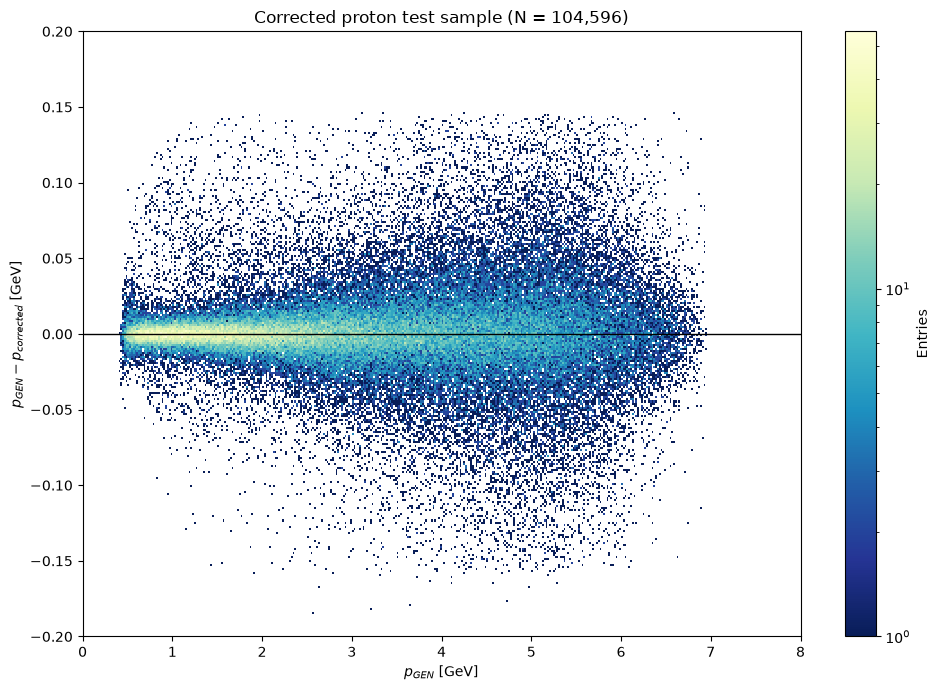

In [27]:
# Corrected delta_p versus generated momentum for the proton test sample.
from matplotlib.colors import LogNorm

p_rec_test_proton = X_test_proton["p_rec"].to_numpy()
p_gen_test_proton = p_rec_test_proton + delta_p_true_proton
p_corrected_test_proton = p_rec_test_proton + delta_p_pred_proton
delta_p_corrected_proton = p_gen_test_proton - p_corrected_test_proton

figure, axis = plt.subplots(figsize=(10, 7), facecolor="white")
histogram = axis.hist2d(
    p_gen_test_proton,
    delta_p_corrected_proton,
    bins=[400, 300],
    range=[[0.0, 8.0], [-0.2, 0.2]],
    norm=LogNorm(),
    cmap="YlGnBu_r",
)
axis.axhline(0.0, color="black", linewidth=1.0)
axis.set_xlabel(r"$p_{GEN}$ [GeV]")
axis.set_ylabel(r"$p_{GEN} - p_{corrected}$ [GeV]")
axis.set_title(
    f"Corrected proton test sample (N = {len(p_gen_test_proton):,})"
)
figure.colorbar(histogram[3], ax=axis, label="Entries")
figure.tight_layout()
plt.show()

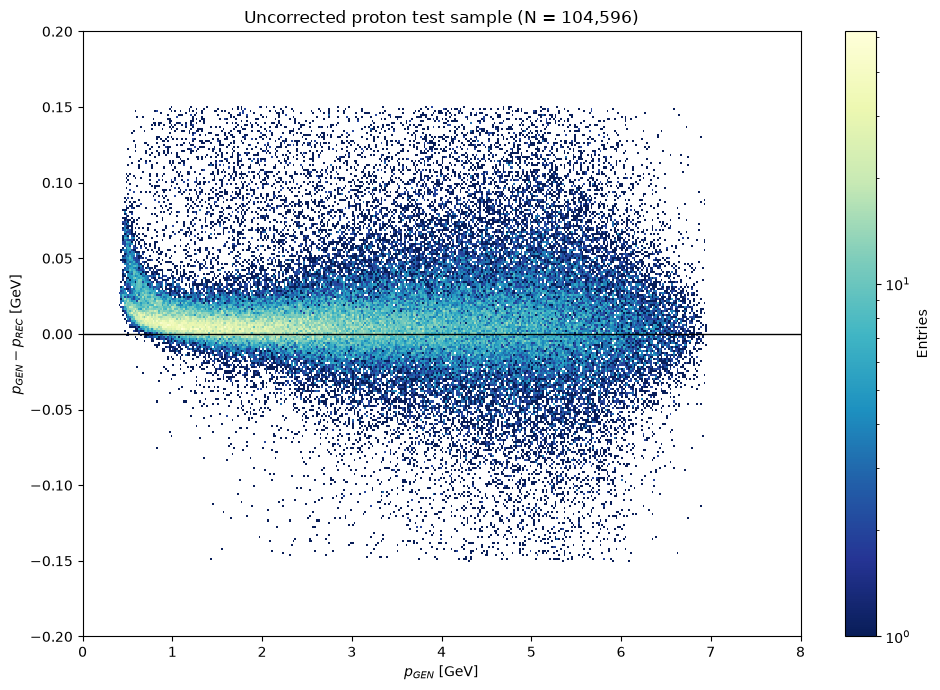

In [28]:
# Uncorrected delta_p versus generated momentum for the proton test sample.
delta_p_uncorrected_proton = p_gen_test_proton - p_rec_test_proton

figure, axis = plt.subplots(figsize=(10, 7), facecolor="white")
histogram = axis.hist2d(
    p_gen_test_proton,
    delta_p_uncorrected_proton,
    bins=[400, 300],
    range=[[0.0, 8.0], [-0.2, 0.2]],
    norm=LogNorm(),
    cmap="YlGnBu_r",
)
axis.axhline(0.0, color="black", linewidth=1.0)
axis.set_xlabel(r"$p_{GEN}$ [GeV]")
axis.set_ylabel(r"$p_{GEN} - p_{REC}$ [GeV]")
axis.set_title(
    f"Uncorrected proton test sample (N = {len(p_gen_test_proton):,})"
)
figure.colorbar(histogram[3], ax=axis, label="Entries")
figure.tight_layout()
plt.show()

In [29]:
# Now let's repeat the same for pi plus!
# Select pi-plus rows after the existing global, FD, and delta-p cuts.
PI_PLUS_PID = 211
PI_PLUS_CUT = GLOBAL_CUT & (ds.field("pid_gen") == PI_PLUS_PID)
df_pi_plus = parquet_dataset.to_table(
    columns=["p_rec", "theta_rec", "phi_rec", "delta_p"],
    filter=PI_PLUS_CUT,
).to_pandas()

# Inputs: reconstructed kinematics
# Target: delta_p = p_gen - p_rec
n_sample_pi_plus = len(df_pi_plus)
df_pi_plus_ml = df_pi_plus.sample(n=n_sample_pi_plus, random_state=42).copy()

X_pi_plus = df_pi_plus_ml[["p_rec", "theta_rec", "phi_rec"]].copy()
y_pi_plus = df_pi_plus_ml["delta_p"].copy()

print("Pi plus rows selected:", f"{n_sample_pi_plus:,}")
print("df_pi_plus_ml shape:", df_pi_plus_ml.shape)
print("X_pi_plus shape:", X_pi_plus.shape)
print("y_pi_plus shape:", y_pi_plus.shape)
print()
print(X_pi_plus.head())
print()
print("Target is delta_p = p_gen - p_rec")

Pi plus rows selected: 508,421
df_pi_plus_ml shape: (508421, 4)
X_pi_plus shape: (508421, 3)
y_pi_plus shape: (508421,)

           p_rec  theta_rec     phi_rec
471802  6.211027  12.554485   66.469139
165741  7.833711   5.804621  129.399841
434098  0.451234  27.989256  174.780762
398081  2.654151  17.561663  175.532700
14904   4.889668  32.905087   93.400841

Target is delta_p = p_gen - p_rec


In [30]:
X_train_pi_plus, X_test_pi_plus, y_train_pi_plus, y_test_pi_plus = train_test_split(
    X_pi_plus,
    y_pi_plus,
    test_size=0.2,
    random_state=42,
)

print("X_train_pi_plus shape:", X_train_pi_plus.shape)
print("X_test_pi_plus shape :", X_test_pi_plus.shape)
print("y_train_pi_plus shape:", y_train_pi_plus.shape)
print("y_test_pi_plus shape :", y_test_pi_plus.shape)

X_train_pi_plus shape: (406736, 3)
X_test_pi_plus shape : (101685, 3)
y_train_pi_plus shape: (406736,)
y_test_pi_plus shape : (101685,)


In [31]:
pi_plus_params = dict(
    objective="reg:absoluteerror",
    tree_method="hist",
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=2,
    min_child_weight=50,
    gamma=1e-4,
    reg_lambda=10.0,
    subsample=0.9,
    colsample_bytree=1.0,
    random_state=42,
)

xgb_pi_plus = XGBRegressor(**pi_plus_params)
xgb_pi_plus.fit(X_train_pi_plus, y_train_pi_plus)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [32]:
tree_df_pi_plus = xgb_pi_plus.get_booster().trees_to_dataframe()

n_trees_pi_plus = tree_df_pi_plus["Tree"].nunique()
n_splits_pi_plus = int((tree_df_pi_plus["Feature"] != "Leaf").sum())
n_leaves_pi_plus = int((tree_df_pi_plus["Feature"] == "Leaf").sum())

train_pred_pi_plus = xgb_pi_plus.predict(X_train_pi_plus)
test_pred_pi_plus = xgb_pi_plus.predict(X_test_pi_plus)

print("Trees:", n_trees_pi_plus)
print("Split nodes:", n_splits_pi_plus)
print("Leaf nodes:", n_leaves_pi_plus)
print()
print("Rows per tree:")
print(tree_df_pi_plus.groupby("Tree").size().describe())
print()
print("y_train_pi_plus std:", np.std(y_train_pi_plus))
print("train prediction std:", np.std(train_pred_pi_plus))
print("test prediction std:", np.std(test_pred_pi_plus))

Trees: 1000
Split nodes: 3000
Leaf nodes: 4000

Rows per tree:
count    1000.0
mean        7.0
std         0.0
min         7.0
25%         7.0
50%         7.0
75%         7.0
max         7.0
dtype: float64

y_train_pi_plus std: 0.040255673
train prediction std: 0.013008306
test prediction std: 0.012940216


In [33]:
# Predict delta_p = p_gen - p_rec for the pi-plus test sample.
delta_p_pred_pi_plus = xgb_pi_plus.predict(X_test_pi_plus)
delta_p_true_pi_plus = y_test_pi_plus.to_numpy()
delta_p_residual_pi_plus = delta_p_pred_pi_plus - delta_p_true_pi_plus

print("delta_p_pred_pi_plus shape:", delta_p_pred_pi_plus.shape)
print("delta_p_true_pi_plus shape:", delta_p_true_pi_plus.shape)
print()
print("Pi-plus prediction residual: delta_p_pred - delta_p_true")
print(f"Mean = {np.mean(delta_p_residual_pi_plus):.6f} GeV")
print(f"Std  = {np.std(delta_p_residual_pi_plus):.6f} GeV")
print(f"MAE  = {np.mean(np.abs(delta_p_residual_pi_plus)):.6f} GeV")

delta_p_pred_pi_plus shape: (101685,)
delta_p_true_pi_plus shape: (101685,)

Pi-plus prediction residual: delta_p_pred - delta_p_true
Mean = -0.000643 GeV
Std  = 0.038135 GeV
MAE  = 0.024633 GeV


In [34]:
mse_pi_plus = mean_squared_error(delta_p_true_pi_plus, delta_p_pred_pi_plus)
rmse_pi_plus = np.sqrt(mse_pi_plus)
mae_pi_plus = mean_absolute_error(delta_p_true_pi_plus, delta_p_pred_pi_plus)
r2_pi_plus = r2_score(delta_p_true_pi_plus, delta_p_pred_pi_plus)

print("Pi-plus delta-p MSE :", mse_pi_plus)
print("Pi-plus delta-p RMSE:", rmse_pi_plus)
print("Pi-plus delta-p MAE :", mae_pi_plus)
print("Pi-plus delta-p R^2 :", r2_pi_plus)

Pi-plus delta-p MSE : 0.001454723416827619
Pi-plus delta-p RMSE: 0.038140836603666926
Pi-plus delta-p MAE : 0.02463257685303688
Pi-plus delta-p R^2 : 0.0970005989074707


Raw pi-plus momentum residual: p_rec - p_gen
  mean = -0.009215 GeV
  std  = 0.040137 GeV
  MAE  = 0.026986 GeV

Corrected pi-plus momentum residual: p_pred - p_gen
  mean = -0.000643 GeV
  std  = 0.038135 GeV
  MAE  = 0.024633 GeV


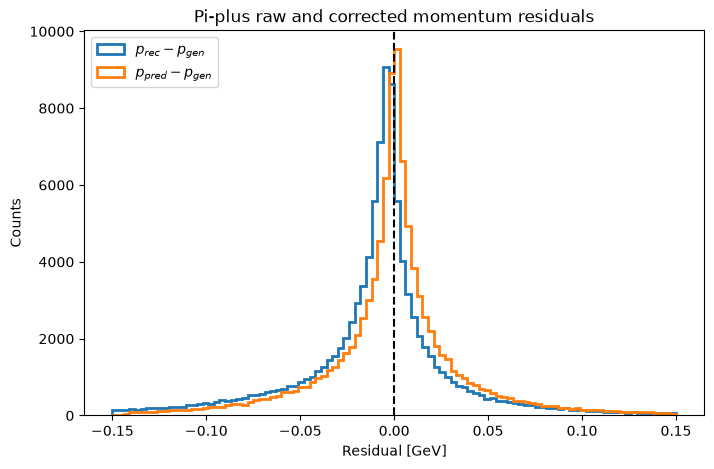

In [35]:
# Reconstruct corrected momentum for the pi-plus test sample.
p_rec_test_pi_plus = X_test_pi_plus["p_rec"].to_numpy()
p_gen_true_pi_plus = p_rec_test_pi_plus + delta_p_true_pi_plus
p_pred_pi_plus = p_rec_test_pi_plus + delta_p_pred_pi_plus

rec_minus_gen_pi_plus = p_rec_test_pi_plus - p_gen_true_pi_plus
pred_minus_gen_pi_plus = p_pred_pi_plus - p_gen_true_pi_plus

print("Raw pi-plus momentum residual: p_rec - p_gen")
print(f"  mean = {np.mean(rec_minus_gen_pi_plus):.6f} GeV")
print(f"  std  = {np.std(rec_minus_gen_pi_plus):.6f} GeV")
print(f"  MAE  = {np.mean(np.abs(rec_minus_gen_pi_plus)):.6f} GeV")
print()
print("Corrected pi-plus momentum residual: p_pred - p_gen")
print(f"  mean = {np.mean(pred_minus_gen_pi_plus):.6f} GeV")
print(f"  std  = {np.std(pred_minus_gen_pi_plus):.6f} GeV")
print(f"  MAE  = {np.mean(np.abs(pred_minus_gen_pi_plus)):.6f} GeV")

plt.figure(figsize=(8, 5))
plt.hist(
    rec_minus_gen_pi_plus,
    bins=100,
    range=[-0.15, 0.15],
    histtype="step",
    linewidth=2,
    label=r"$p_{rec}-p_{gen}$",
)
plt.hist(
    pred_minus_gen_pi_plus,
    bins=100,
    range=[-0.15, 0.15],
    histtype="step",
    linewidth=2,
    label=r"$p_{pred}-p_{gen}$",
)
plt.xlabel("Residual [GeV]")
plt.ylabel("Counts")
plt.title("Pi-plus raw and corrected momentum residuals")
plt.axvline(0.0, color="black", linestyle="--")
plt.legend(loc="upper left")
plt.show()

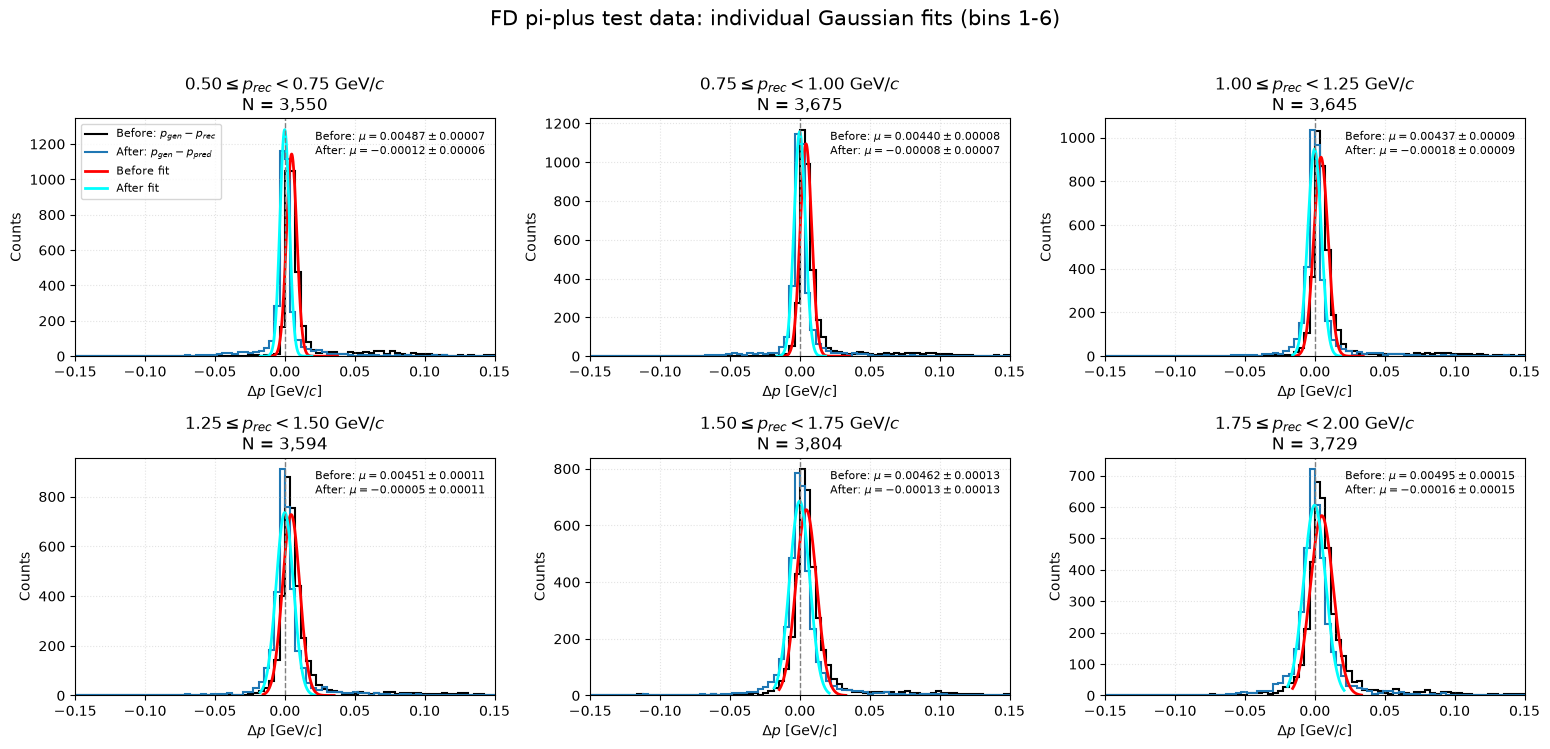

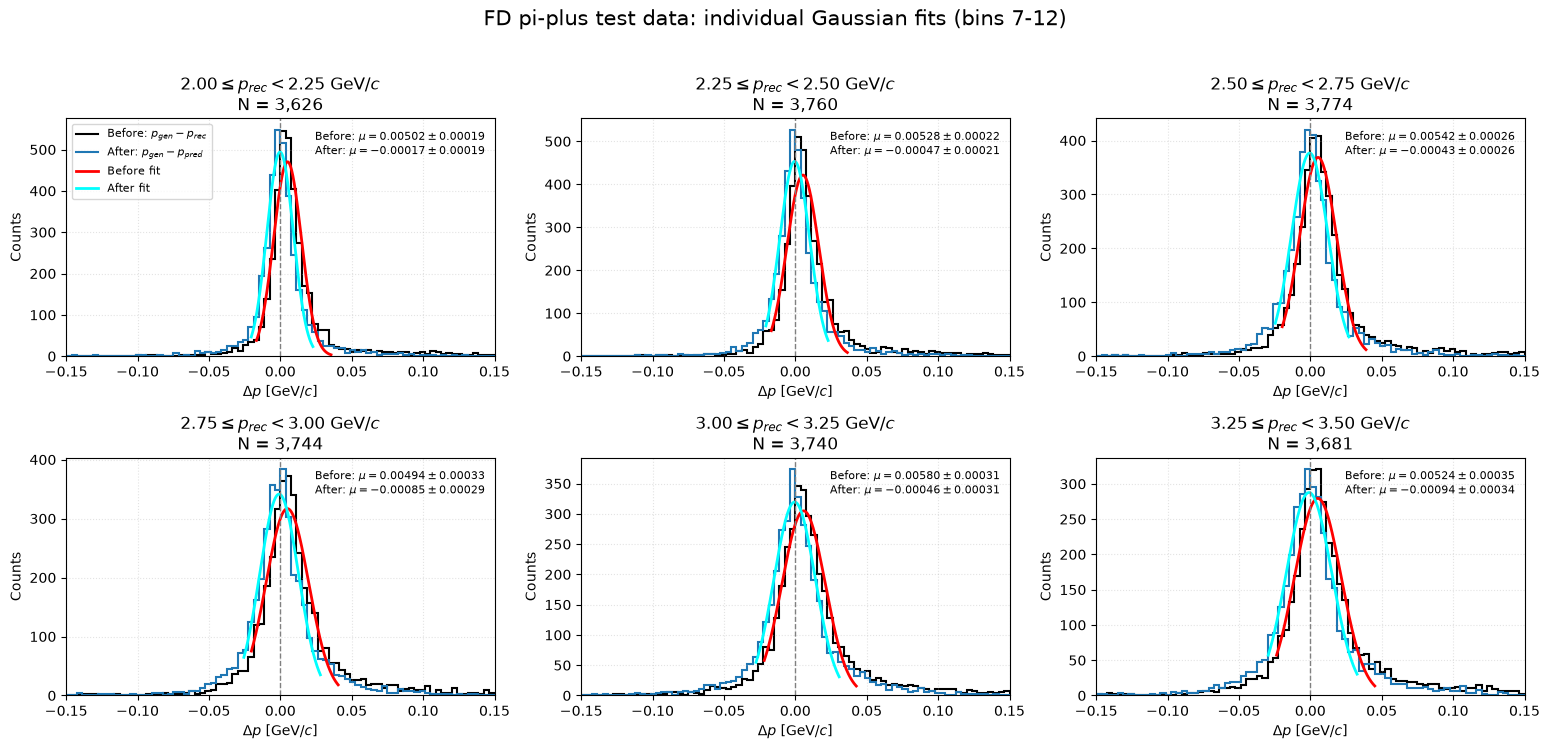

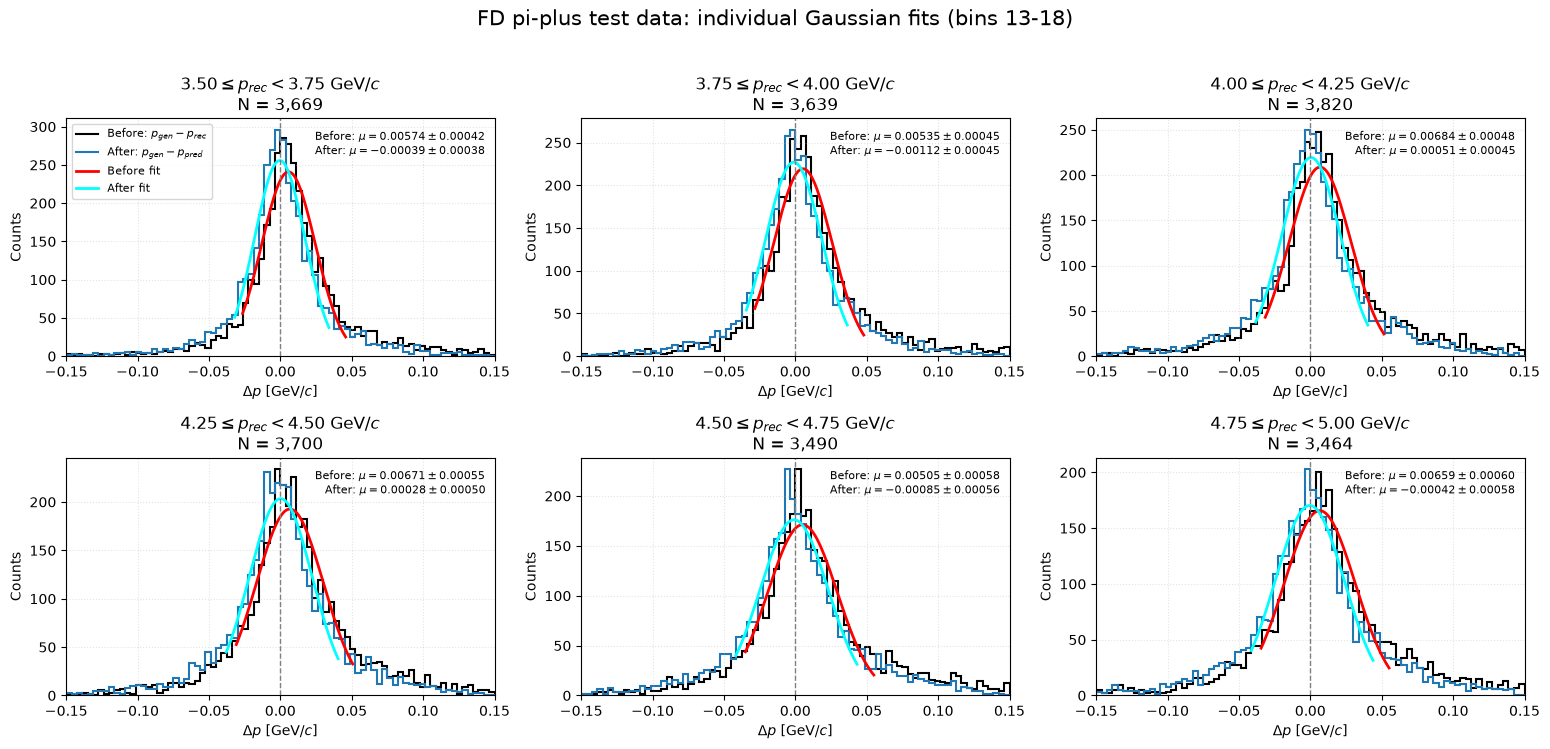

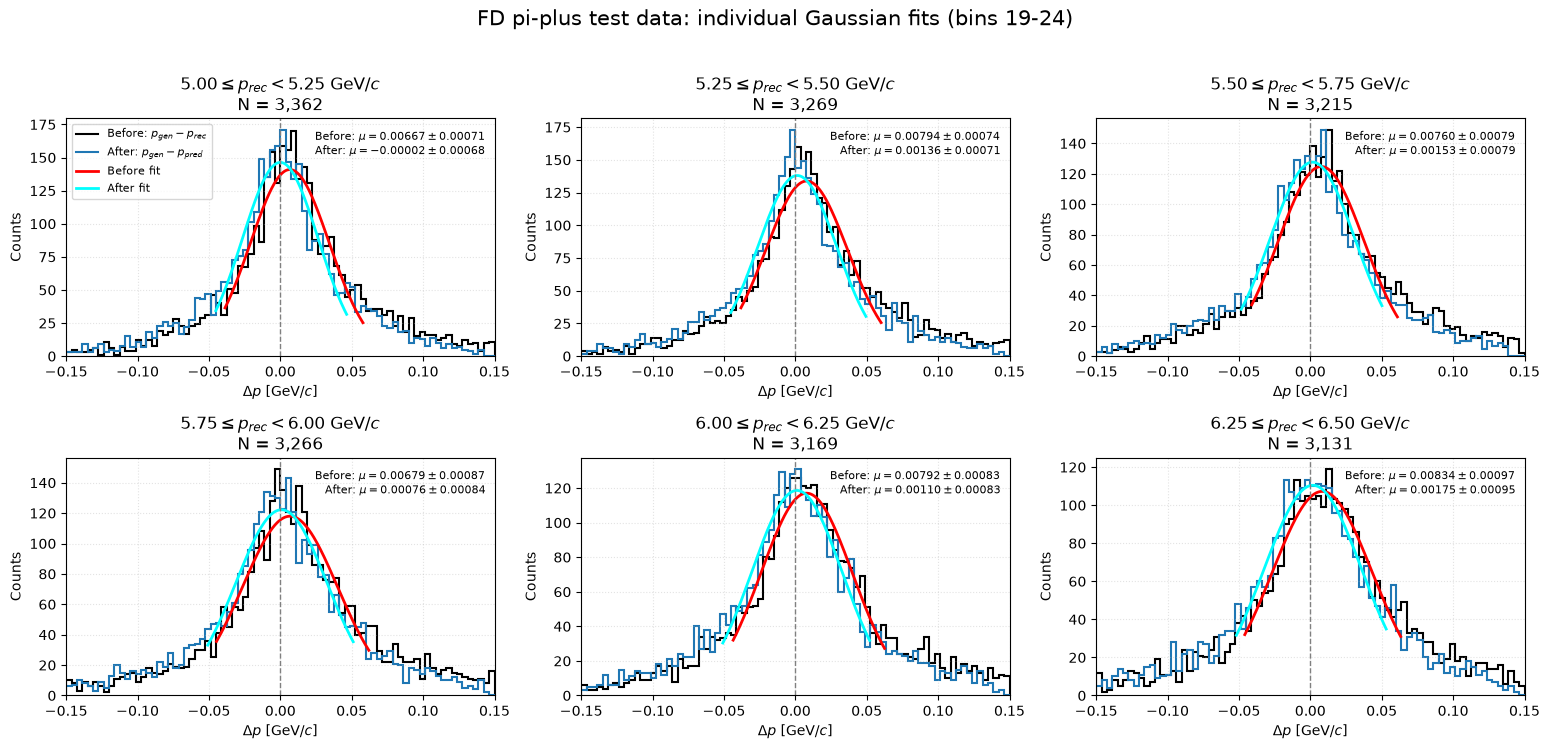

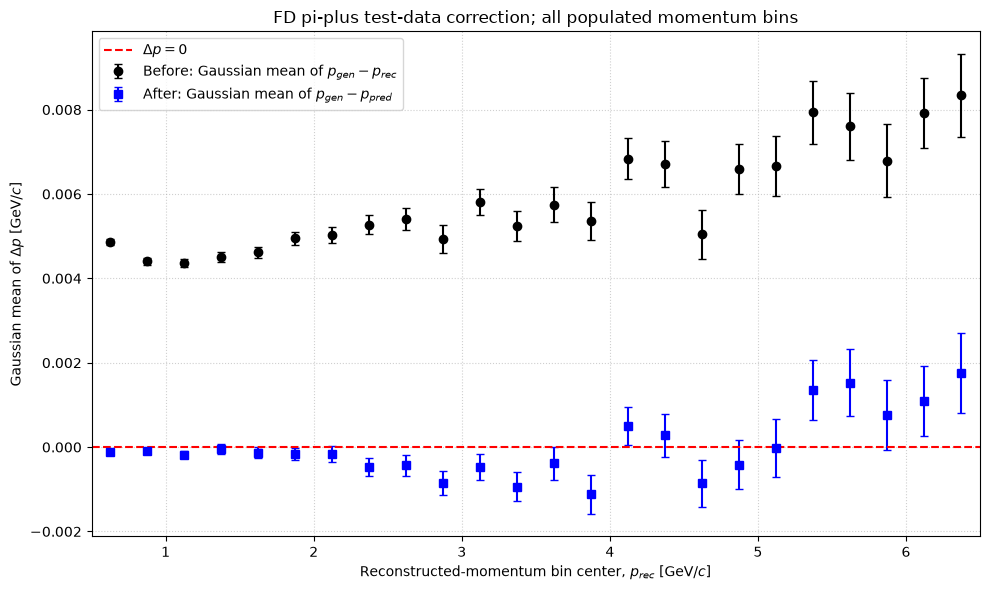

In [36]:
# Gaussian mean before/after correction versus p_rec for pi-plus test data.
p_rec_fit_pi_plus = X_test_pi_plus["p_rec"].to_numpy()
delta_p_before_pi_plus = delta_p_true_pi_plus
delta_p_after_pi_plus = delta_p_true_pi_plus - delta_p_pred_pi_plus

PI_PLUS_MOMENTUM_BIN_WIDTH = 0.25
PI_PLUS_MOMENTUM_MIN = 0.5
PI_PLUS_MOMENTUM_MAX = 6.5
pi_plus_momentum_edges = np.arange(
    PI_PLUS_MOMENTUM_MIN,
    PI_PLUS_MOMENTUM_MAX + 0.5 * PI_PLUS_MOMENTUM_BIN_WIDTH,
    PI_PLUS_MOMENTUM_BIN_WIDTH,
)

pi_plus_momentum_fit_details = []
pi_plus_momentum_fit_records = []

for p_low, p_high in zip(pi_plus_momentum_edges[:-1], pi_plus_momentum_edges[1:]):
    bin_mask = (p_rec_fit_pi_plus >= p_low) & (p_rec_fit_pi_plus < p_high)
    bin_entries = int(np.count_nonzero(bin_mask))
    if bin_entries == 0:
        print(f"Empty pi-plus momentum bin: {p_low:.2f}-{p_high:.2f} GeV/c")
        continue

    before_fit = fit_gaussian_peak_one_sigma(delta_p_before_pi_plus[bin_mask])
    after_fit = fit_gaussian_peak_one_sigma(delta_p_after_pi_plus[bin_mask])
    if before_fit is None or after_fit is None:
        raise RuntimeError(
            f"Could not fit populated pi-plus bin {p_low:.2f}-{p_high:.2f} GeV/c"
        )

    pi_plus_momentum_fit_details.append(
        {
            "p_low": p_low,
            "p_high": p_high,
            "entries": bin_entries,
            "before": before_fit,
            "after": after_fit,
        }
    )
    pi_plus_momentum_fit_records.append(
        {
            "p_center": 0.5 * (p_low + p_high),
            "entries": bin_entries,
            "before_mean": before_fit["mean"],
            "before_mean_error": before_fit["mean_error"],
            "after_mean": after_fit["mean"],
            "after_mean_error": after_fit["mean_error"],
        }
    )

gaussian_mean_vs_momentum_pi_plus = pd.DataFrame(pi_plus_momentum_fit_records)

# Inspect every individual fitted momentum bin.
PI_PLUS_FITS_PER_FIGURE = 6
for page_start in range(
    0,
    len(pi_plus_momentum_fit_details),
    PI_PLUS_FITS_PER_FIGURE,
):
    page_details = pi_plus_momentum_fit_details[
        page_start:page_start + PI_PLUS_FITS_PER_FIGURE
    ]
    ncols = 3
    nrows = int(np.ceil(len(page_details) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(5.2 * ncols, 3.8 * nrows), squeeze=False
    )
    axes = axes.ravel()

    for panel_index, fit_data in enumerate(page_details):
        ax = axes[panel_index]
        before_fit = fit_data["before"]
        after_fit = fit_data["after"]
        ax.stairs(
            before_fit["counts"], before_fit["edges"],
            color="black", linewidth=1.5, label=r"Before: $p_{gen}-p_{rec}$",
        )
        ax.stairs(
            after_fit["counts"], after_fit["edges"],
            color="tab:blue", linewidth=1.5, label=r"After: $p_{gen}-p_{pred}$",
        )
        before_x = np.linspace(before_fit["fit_low"], before_fit["fit_high"], 400)
        after_x = np.linspace(after_fit["fit_low"], after_fit["fit_high"], 400)
        ax.plot(
            before_x, gaussian_no_rejection(before_x, *before_fit["parameters"]),
            color="red", linewidth=2.0, label="Before fit",
        )
        ax.plot(
            after_x, gaussian_no_rejection(after_x, *after_fit["parameters"]),
            color="cyan", linewidth=2.0, label="After fit",
        )
        ax.axvline(0.0, color="gray", linestyle="--", linewidth=1.0)
        ax.set_xlim(RESIDUAL_LIMITS)
        ax.set_xlabel(r"$\Delta p$ [GeV/$c$]")
        ax.set_ylabel("Counts")
        ax.set_title(
            rf"${fit_data['p_low']:.2f} \leq p_{{rec}} < {fit_data['p_high']:.2f}$ GeV/$c$"
            f"\nN = {fit_data['entries']:,}"
        )
        ax.grid(True, linestyle=":", alpha=0.35)
        fit_text = (
            rf"Before: $\mu={before_fit['mean']:.5f} \pm {before_fit['mean_error']:.5f}$"
            "\n"
            rf"After: $\mu={after_fit['mean']:.5f} \pm {after_fit['mean_error']:.5f}$"
        )
        ax.text(
            0.98, 0.95, fit_text, transform=ax.transAxes,
            ha="right", va="top", fontsize=8,
        )
        if panel_index == 0:
            ax.legend(loc="upper left", fontsize=8)

    for unused_axis in axes[len(page_details):]:
        unused_axis.set_visible(False)
    page_end = page_start + len(page_details)
    fig.suptitle(
        f"FD pi-plus test data: individual Gaussian fits "
        f"(bins {page_start + 1}-{page_end})",
        fontsize=15,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()
    plt.close(fig)

# Summary of fitted Gaussian means.
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    gaussian_mean_vs_momentum_pi_plus["p_center"],
    gaussian_mean_vs_momentum_pi_plus["before_mean"],
    yerr=gaussian_mean_vs_momentum_pi_plus["before_mean_error"],
    fmt="o", color="black", capsize=3, linestyle="none",
    label=r"Before: Gaussian mean of $p_{gen}-p_{rec}$",
)
ax.errorbar(
    gaussian_mean_vs_momentum_pi_plus["p_center"],
    gaussian_mean_vs_momentum_pi_plus["after_mean"],
    yerr=gaussian_mean_vs_momentum_pi_plus["after_mean_error"],
    fmt="s", color="blue", capsize=3, linestyle="none",
    label=r"After: Gaussian mean of $p_{gen}-p_{pred}$",
)
ax.axhline(0.0, color="red", linestyle="--", linewidth=1.5, label=r"$\Delta p=0$")
ax.set_xlim(pi_plus_momentum_edges[0], pi_plus_momentum_edges[-1])
ax.set_xlabel(r"Reconstructed-momentum bin center, $p_{rec}$ [GeV/$c$]")
ax.set_ylabel(r"Gaussian mean of $\Delta p$ [GeV/$c$]")
ax.set_title("FD pi-plus test-data correction; all populated momentum bins")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)

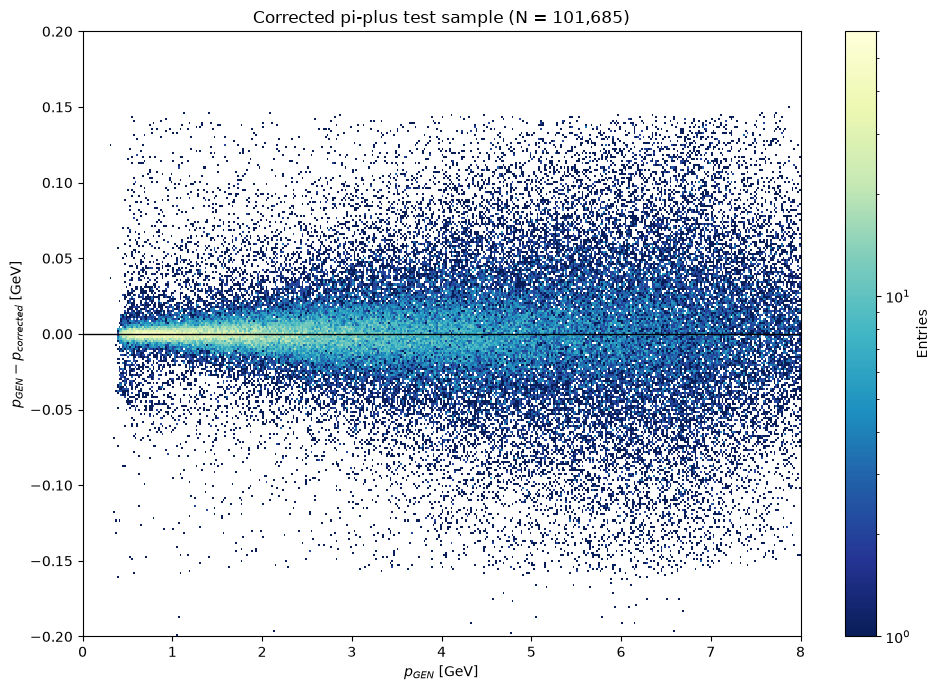

In [37]:
# Corrected delta_p versus generated momentum for the pi-plus test sample.
p_gen_test_pi_plus = p_rec_test_pi_plus + delta_p_true_pi_plus
p_corrected_test_pi_plus = p_rec_test_pi_plus + delta_p_pred_pi_plus
delta_p_corrected_pi_plus = p_gen_test_pi_plus - p_corrected_test_pi_plus

figure, axis = plt.subplots(figsize=(10, 7), facecolor="white")
histogram = axis.hist2d(
    p_gen_test_pi_plus,
    delta_p_corrected_pi_plus,
    bins=[400, 300],
    range=[[0.0, 8.0], [-0.2, 0.2]],
    norm=LogNorm(),
    cmap="YlGnBu_r",
)
axis.axhline(0.0, color="black", linewidth=1.0)
axis.set_xlabel(r"$p_{GEN}$ [GeV]")
axis.set_ylabel(r"$p_{GEN} - p_{corrected}$ [GeV]")
axis.set_title(f"Corrected pi-plus test sample (N = {len(p_gen_test_pi_plus):,})")
figure.colorbar(histogram[3], ax=axis, label="Entries")
figure.tight_layout()
plt.show()

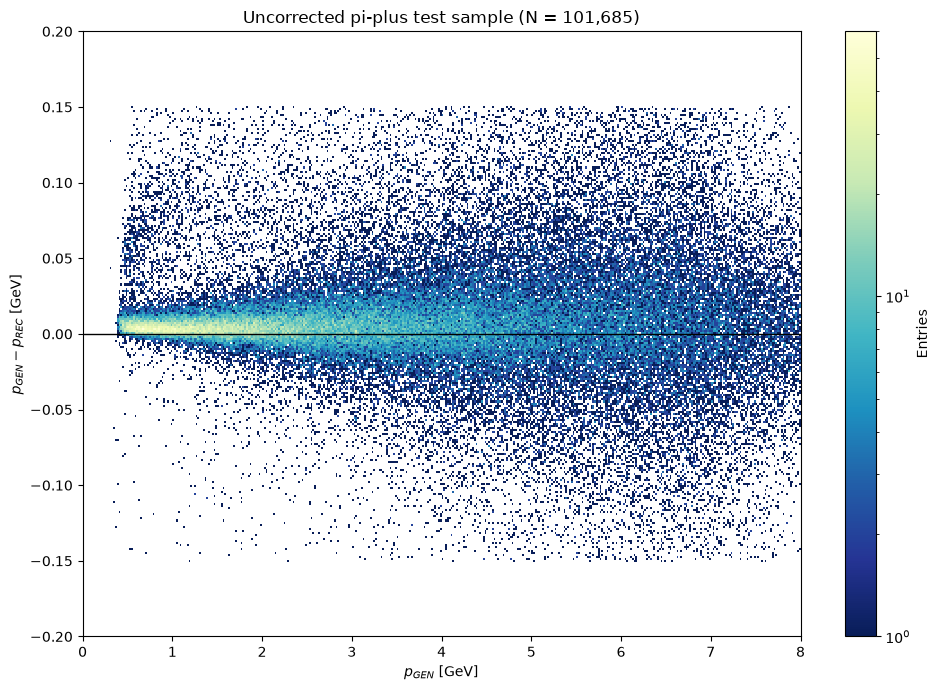

In [38]:
# Uncorrected delta_p versus generated momentum for the pi-plus test sample.
delta_p_uncorrected_pi_plus = p_gen_test_pi_plus - p_rec_test_pi_plus

figure, axis = plt.subplots(figsize=(10, 7), facecolor="white")
histogram = axis.hist2d(
    p_gen_test_pi_plus,
    delta_p_uncorrected_pi_plus,
    bins=[400, 300],
    range=[[0.0, 8.0], [-0.2, 0.2]],
    norm=LogNorm(),
    cmap="YlGnBu_r",
)
axis.axhline(0.0, color="black", linewidth=1.0)
axis.set_xlabel(r"$p_{GEN}$ [GeV]")
axis.set_ylabel(r"$p_{GEN} - p_{REC}$ [GeV]")
axis.set_title(f"Uncorrected pi-plus test sample (N = {len(p_gen_test_pi_plus):,})")
figure.colorbar(histogram[3], ax=axis, label="Entries")
figure.tight_layout()
plt.show()

In [46]:
# Now let's repeat the same for pi minus!
# Select pi-minus rows after the existing global, FD, and delta-p cuts.
PI_MINUS_PID = -211
PI_MINUS_CUT = GLOBAL_CUT & (ds.field("pid_gen") == PI_MINUS_PID)
df_pi_minus = parquet_dataset.to_table(
    columns=["p_rec", "theta_rec", "phi_rec", "delta_p"],
    filter=PI_MINUS_CUT,
).to_pandas()

# Inputs: reconstructed kinematics
# Target: delta_p = p_gen - p_rec
n_sample_pi_minus = len(df_pi_minus)
df_pi_minus_ml = df_pi_minus.sample(n=n_sample_pi_minus, random_state=42).copy()

X_pi_minus = df_pi_minus_ml[["p_rec", "theta_rec", "phi_rec"]].copy()
y_pi_minus = df_pi_minus_ml["delta_p"].copy()

print("Pi minus rows selected:", f"{n_sample_pi_minus:,}")
print("df_pi_minus_ml shape:", df_pi_minus_ml.shape)
print("X_pi_minus shape:", X_pi_minus.shape)
print("y_pi_minus shape:", y_pi_minus.shape)
print()
print(X_pi_minus.head())
print()
print("Target is delta_p = p_gen - p_rec")

Pi minus rows selected: 441,363
df_pi_minus_ml shape: (441363, 4)
X_pi_minus shape: (441363, 3)
y_pi_minus shape: (441363,)

           p_rec  theta_rec     phi_rec
313808  8.262218  12.980770   76.564079
429425  0.897243  19.169832  161.360092
199914  6.822443  28.365347  116.730820
279660  4.934520   9.684299 -113.534218
398776  7.247056  31.529734  -90.137047

Target is delta_p = p_gen - p_rec


In [47]:
X_train_pi_minus, X_test_pi_minus, y_train_pi_minus, y_test_pi_minus = train_test_split(
    X_pi_minus,
    y_pi_minus,
    test_size=0.2,
    random_state=42,
)

print("X_train_pi_minus shape:", X_train_pi_minus.shape)
print("X_test_pi_minus shape :", X_test_pi_minus.shape)
print("y_train_pi_minus shape:", y_train_pi_minus.shape)
print("y_test_pi_minus shape :", y_test_pi_minus.shape)

X_train_pi_minus shape: (353090, 3)
X_test_pi_minus shape : (88273, 3)
y_train_pi_minus shape: (353090,)
y_test_pi_minus shape : (88273,)


In [48]:
pi_minus_params = dict(
    objective="reg:absoluteerror",
    tree_method="hist",
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=2,
    min_child_weight=50,
    gamma=1e-4,
    reg_lambda=10.0,
    subsample=0.9,
    colsample_bytree=1.0,
    random_state=42,
)

xgb_pi_minus = XGBRegressor(**pi_minus_params)
xgb_pi_minus.fit(X_train_pi_minus, y_train_pi_minus)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [49]:
tree_df_pi_minus = xgb_pi_minus.get_booster().trees_to_dataframe()

n_trees_pi_minus = tree_df_pi_minus["Tree"].nunique()
n_splits_pi_minus = int((tree_df_pi_minus["Feature"] != "Leaf").sum())
n_leaves_pi_minus = int((tree_df_pi_minus["Feature"] == "Leaf").sum())

train_pred_pi_minus = xgb_pi_minus.predict(X_train_pi_minus)
test_pred_pi_minus = xgb_pi_minus.predict(X_test_pi_minus)

print("Trees:", n_trees_pi_minus)
print("Split nodes:", n_splits_pi_minus)
print("Leaf nodes:", n_leaves_pi_minus)
print()
print("Rows per tree:")
print(tree_df_pi_minus.groupby("Tree").size().describe())
print()
print("y_train_pi_minus std:", np.std(y_train_pi_minus))
print("train prediction std:", np.std(train_pred_pi_minus))
print("test prediction std:", np.std(test_pred_pi_minus))

Trees: 1000
Split nodes: 3000
Leaf nodes: 4000

Rows per tree:
count    1000.0
mean        7.0
std         0.0
min         7.0
25%         7.0
50%         7.0
75%         7.0
max         7.0
dtype: float64

y_train_pi_minus std: 0.04233473
train prediction std: 0.013789366
test prediction std: 0.013822016


In [50]:
# Predict delta_p = p_gen - p_rec for the pi-minus test sample.
delta_p_pred_pi_minus = xgb_pi_minus.predict(X_test_pi_minus)
delta_p_true_pi_minus = y_test_pi_minus.to_numpy()
delta_p_residual_pi_minus = delta_p_pred_pi_minus - delta_p_true_pi_minus

print("delta_p_pred_pi_minus shape:", delta_p_pred_pi_minus.shape)
print("delta_p_true_pi_minus shape:", delta_p_true_pi_minus.shape)
print()
print("Pi-plus prediction residual: delta_p_pred - delta_p_true")
print(f"Mean = {np.mean(delta_p_residual_pi_minus):.6f} GeV")
print(f"Std  = {np.std(delta_p_residual_pi_minus):.6f} GeV")
print(f"MAE  = {np.mean(np.abs(delta_p_residual_pi_minus)):.6f} GeV")

delta_p_pred_pi_minus shape: (88273,)
delta_p_true_pi_minus shape: (88273,)

Pi-plus prediction residual: delta_p_pred - delta_p_true
Mean = -0.000485 GeV
Std  = 0.040144 GeV
MAE  = 0.026816 GeV


In [51]:
mse_pi_minus = mean_squared_error(delta_p_true_pi_minus, delta_p_pred_pi_minus)
rmse_pi_minus = np.sqrt(mse_pi_minus)
mae_pi_minus = mean_absolute_error(delta_p_true_pi_minus, delta_p_pred_pi_minus)
r2_pi_minus = r2_score(delta_p_true_pi_minus, delta_p_pred_pi_minus)

print("Pi-plus delta-p MSE :", mse_pi_minus)
print("Pi-plus delta-p RMSE:", rmse_pi_minus)
print("Pi-plus delta-p MAE :", mae_pi_minus)
print("Pi-plus delta-p R^2 :", r2_pi_minus)

Pi-plus delta-p MSE : 0.0016117476625368
Pi-plus delta-p RMSE: 0.040146577220689685
Pi-plus delta-p MAE : 0.026816239580512047
Pi-plus delta-p R^2 : 0.0987544059753418


Raw pi-minus momentum residual: p_rec - p_gen
  mean = -0.009951 GeV
  std  = 0.042289 GeV
  MAE  = 0.029317 GeV

Corrected pi-minus momentum residual: p_pred - p_gen
  mean = -0.000485 GeV
  std  = 0.040144 GeV
  MAE  = 0.026816 GeV


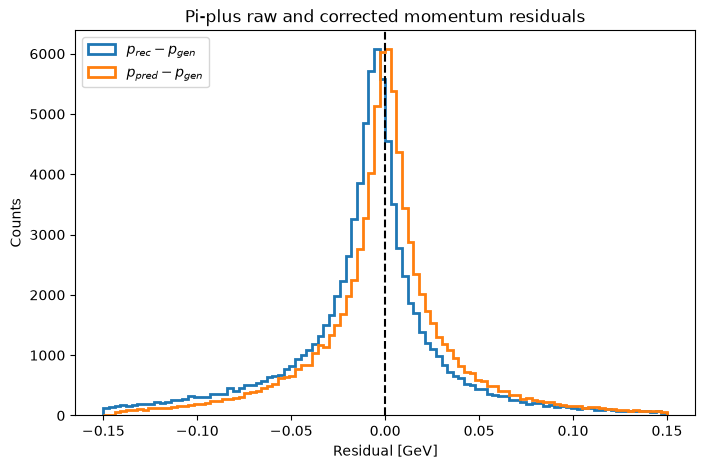

In [52]:
# Reconstruct corrected momentum for the pi-minus test sample.
p_rec_test_pi_minus = X_test_pi_minus["p_rec"].to_numpy()
p_gen_true_pi_minus = p_rec_test_pi_minus + delta_p_true_pi_minus
p_pred_pi_minus = p_rec_test_pi_minus + delta_p_pred_pi_minus

rec_minus_gen_pi_minus = p_rec_test_pi_minus - p_gen_true_pi_minus
pred_minus_gen_pi_minus = p_pred_pi_minus - p_gen_true_pi_minus

print("Raw pi-minus momentum residual: p_rec - p_gen")
print(f"  mean = {np.mean(rec_minus_gen_pi_minus):.6f} GeV")
print(f"  std  = {np.std(rec_minus_gen_pi_minus):.6f} GeV")
print(f"  MAE  = {np.mean(np.abs(rec_minus_gen_pi_minus)):.6f} GeV")
print()
print("Corrected pi-minus momentum residual: p_pred - p_gen")
print(f"  mean = {np.mean(pred_minus_gen_pi_minus):.6f} GeV")
print(f"  std  = {np.std(pred_minus_gen_pi_minus):.6f} GeV")
print(f"  MAE  = {np.mean(np.abs(pred_minus_gen_pi_minus)):.6f} GeV")

plt.figure(figsize=(8, 5))
plt.hist(
    rec_minus_gen_pi_minus,
    bins=100,
    range=[-0.15, 0.15],
    histtype="step",
    linewidth=2,
    label=r"$p_{rec}-p_{gen}$",
)
plt.hist(
    pred_minus_gen_pi_minus,
    bins=100,
    range=[-0.15, 0.15],
    histtype="step",
    linewidth=2,
    label=r"$p_{pred}-p_{gen}$",
)
plt.xlabel("Residual [GeV]")
plt.ylabel("Counts")
plt.title("Pi-plus raw and corrected momentum residuals")
plt.axvline(0.0, color="black", linestyle="--")
plt.legend(loc="upper left")
plt.show()

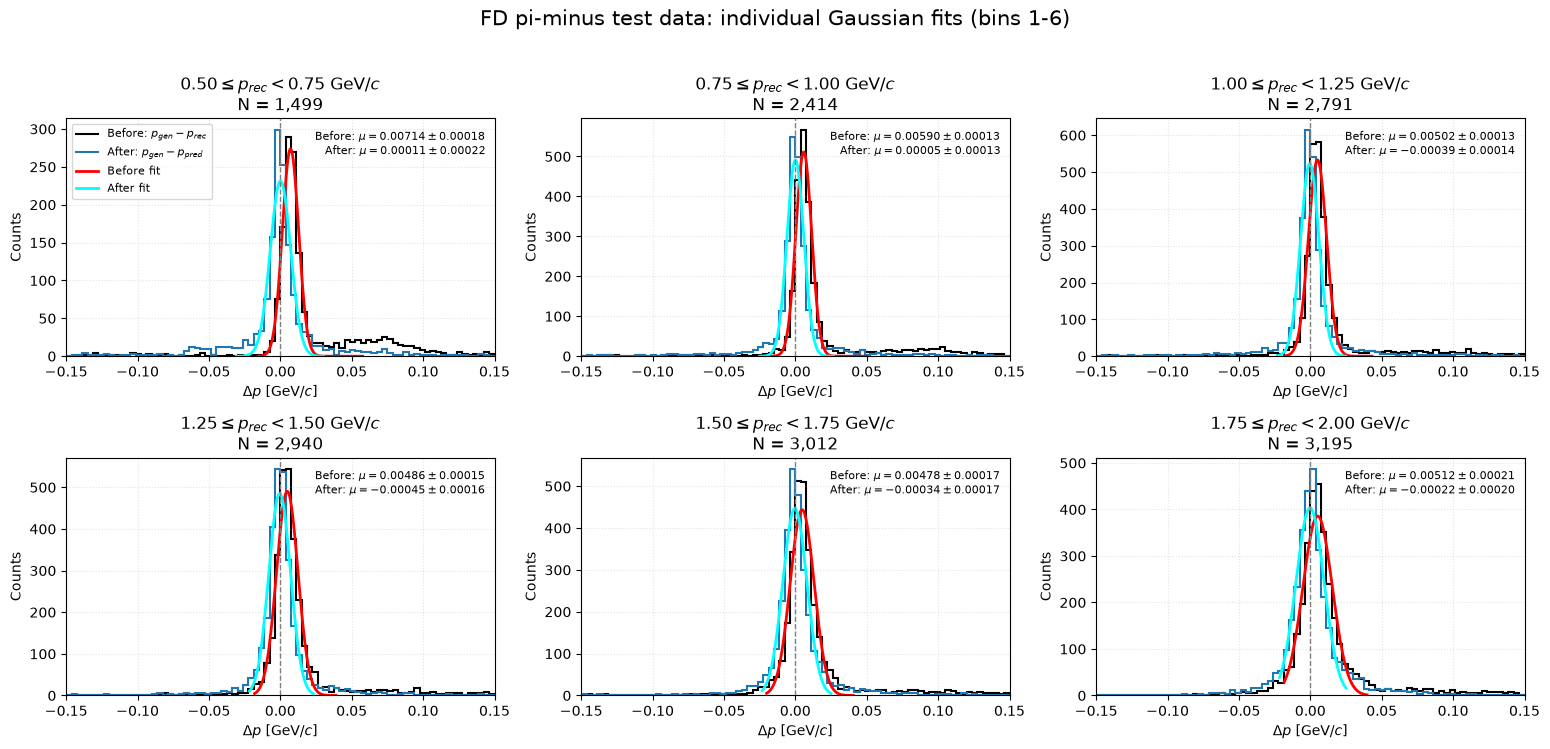

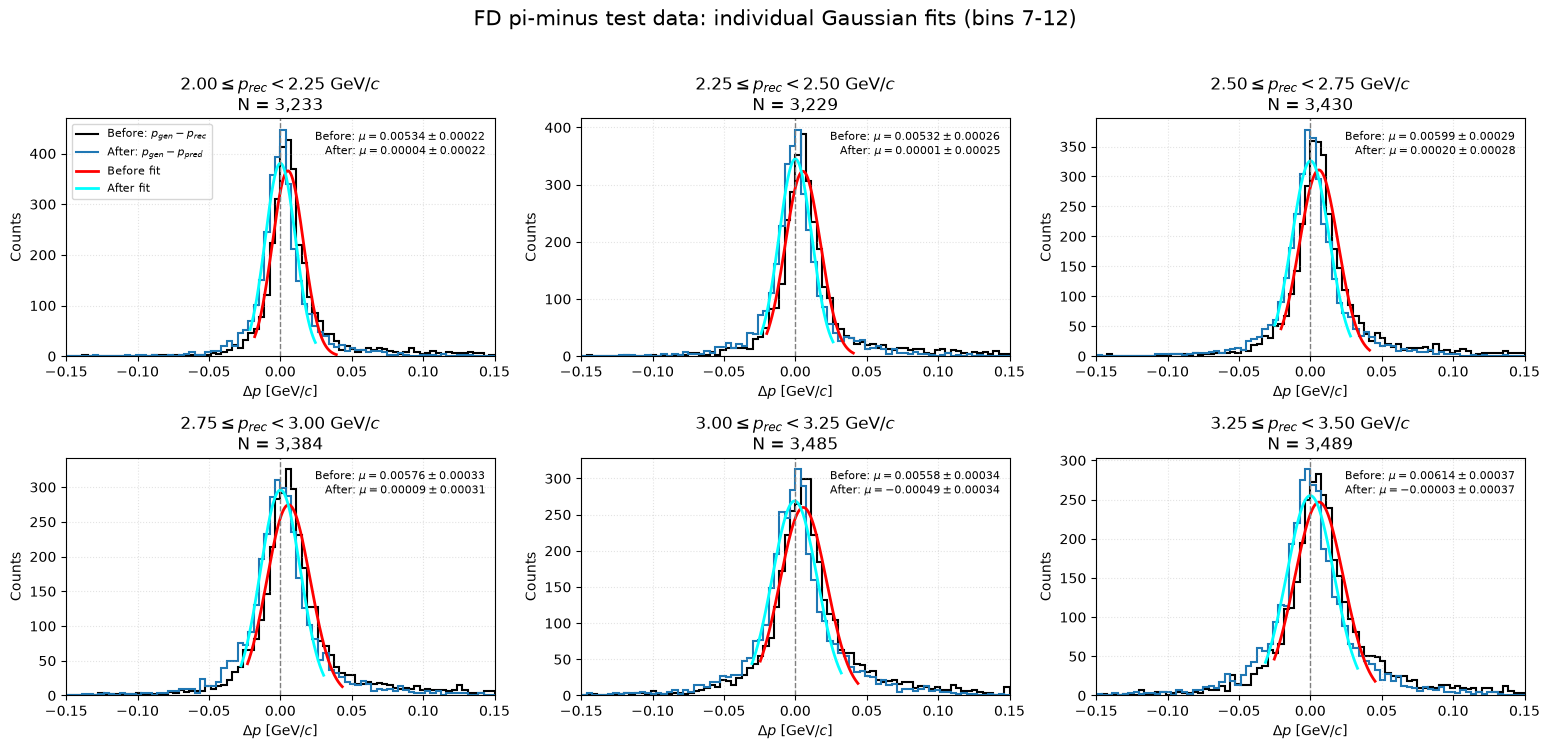

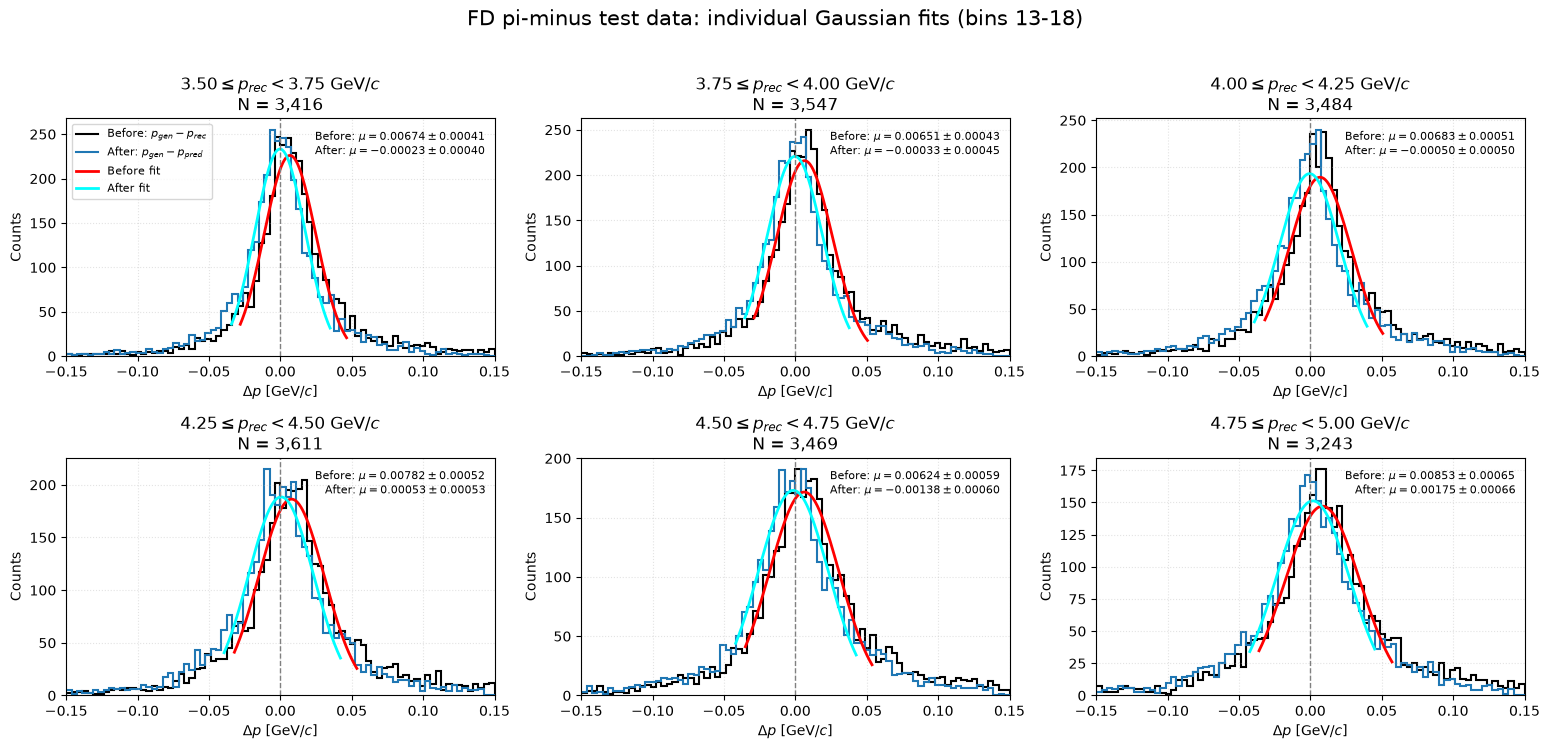

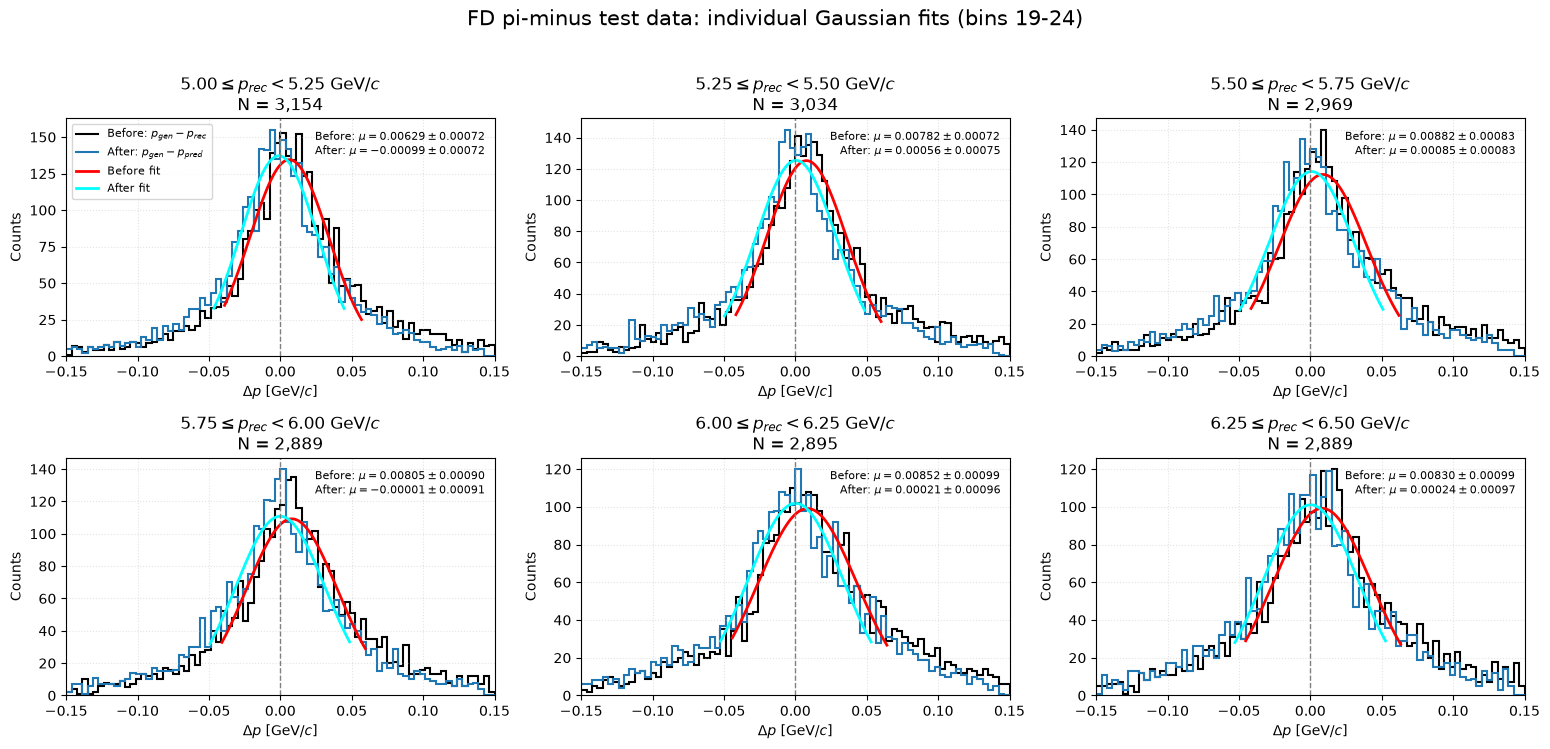

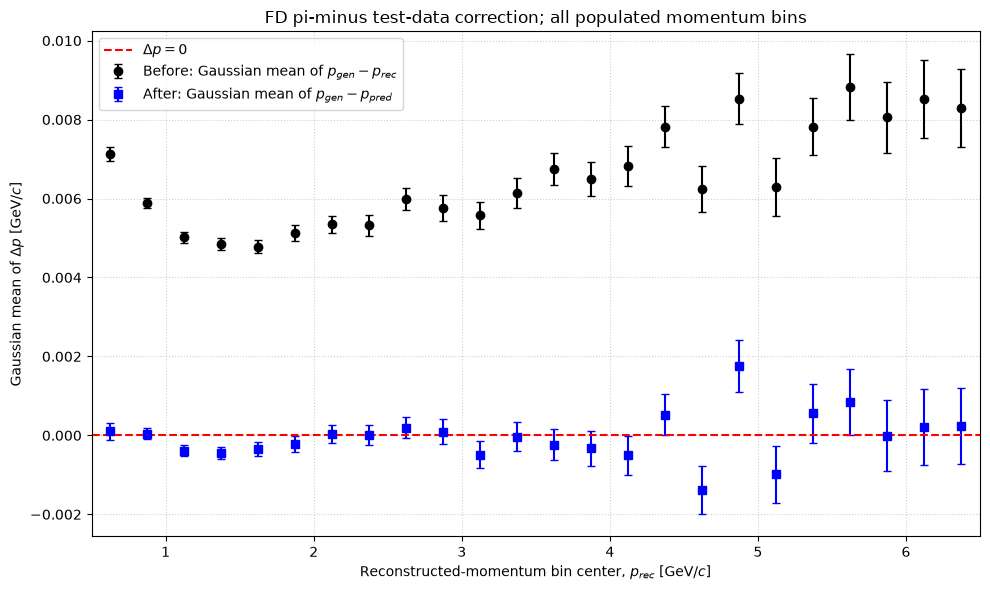

In [53]:
# Gaussian mean before/after correction versus p_rec for pi-minus test data.
p_rec_fit_pi_minus = X_test_pi_minus["p_rec"].to_numpy()
delta_p_before_pi_minus = delta_p_true_pi_minus
delta_p_after_pi_minus = delta_p_true_pi_minus - delta_p_pred_pi_minus

PI_MINUS_MOMENTUM_BIN_WIDTH = 0.25
PI_MINUS_MOMENTUM_MIN = 0.5
PI_MINUS_MOMENTUM_MAX = 6.5
pi_minus_momentum_edges = np.arange(
    PI_MINUS_MOMENTUM_MIN,
    PI_MINUS_MOMENTUM_MAX + 0.5 * PI_MINUS_MOMENTUM_BIN_WIDTH,
    PI_MINUS_MOMENTUM_BIN_WIDTH,
)

pi_minus_momentum_fit_details = []
pi_minus_momentum_fit_records = []

for p_low, p_high in zip(pi_minus_momentum_edges[:-1], pi_minus_momentum_edges[1:]):
    bin_mask = (p_rec_fit_pi_minus >= p_low) & (p_rec_fit_pi_minus < p_high)
    bin_entries = int(np.count_nonzero(bin_mask))
    if bin_entries == 0:
        print(f"Empty pi-minus momentum bin: {p_low:.2f}-{p_high:.2f} GeV/c")
        continue

    before_fit = fit_gaussian_peak_one_sigma(delta_p_before_pi_minus[bin_mask])
    after_fit = fit_gaussian_peak_one_sigma(delta_p_after_pi_minus[bin_mask])
    if before_fit is None or after_fit is None:
        raise RuntimeError(
            f"Could not fit populated pi-minus bin {p_low:.2f}-{p_high:.2f} GeV/c"
        )

    pi_minus_momentum_fit_details.append(
        {
            "p_low": p_low,
            "p_high": p_high,
            "entries": bin_entries,
            "before": before_fit,
            "after": after_fit,
        }
    )
    pi_minus_momentum_fit_records.append(
        {
            "p_center": 0.5 * (p_low + p_high),
            "entries": bin_entries,
            "before_mean": before_fit["mean"],
            "before_mean_error": before_fit["mean_error"],
            "after_mean": after_fit["mean"],
            "after_mean_error": after_fit["mean_error"],
        }
    )

gaussian_mean_vs_momentum_pi_minus = pd.DataFrame(pi_minus_momentum_fit_records)

# Inspect every individual fitted momentum bin.
PI_MINUS_FITS_PER_FIGURE = 6
for page_start in range(
    0,
    len(pi_minus_momentum_fit_details),
    PI_MINUS_FITS_PER_FIGURE,
):
    page_details = pi_minus_momentum_fit_details[
        page_start:page_start + PI_MINUS_FITS_PER_FIGURE
    ]
    ncols = 3
    nrows = int(np.ceil(len(page_details) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(5.2 * ncols, 3.8 * nrows), squeeze=False
    )
    axes = axes.ravel()

    for panel_index, fit_data in enumerate(page_details):
        ax = axes[panel_index]
        before_fit = fit_data["before"]
        after_fit = fit_data["after"]
        ax.stairs(
            before_fit["counts"], before_fit["edges"],
            color="black", linewidth=1.5, label=r"Before: $p_{gen}-p_{rec}$",
        )
        ax.stairs(
            after_fit["counts"], after_fit["edges"],
            color="tab:blue", linewidth=1.5, label=r"After: $p_{gen}-p_{pred}$",
        )
        before_x = np.linspace(before_fit["fit_low"], before_fit["fit_high"], 400)
        after_x = np.linspace(after_fit["fit_low"], after_fit["fit_high"], 400)
        ax.plot(
            before_x, gaussian_no_rejection(before_x, *before_fit["parameters"]),
            color="red", linewidth=2.0, label="Before fit",
        )
        ax.plot(
            after_x, gaussian_no_rejection(after_x, *after_fit["parameters"]),
            color="cyan", linewidth=2.0, label="After fit",
        )
        ax.axvline(0.0, color="gray", linestyle="--", linewidth=1.0)
        ax.set_xlim(RESIDUAL_LIMITS)
        ax.set_xlabel(r"$\Delta p$ [GeV/$c$]")
        ax.set_ylabel("Counts")
        ax.set_title(
            rf"${fit_data['p_low']:.2f} \leq p_{{rec}} < {fit_data['p_high']:.2f}$ GeV/$c$"
            f"\nN = {fit_data['entries']:,}"
        )
        ax.grid(True, linestyle=":", alpha=0.35)
        fit_text = (
            rf"Before: $\mu={before_fit['mean']:.5f} \pm {before_fit['mean_error']:.5f}$"
            "\n"
            rf"After: $\mu={after_fit['mean']:.5f} \pm {after_fit['mean_error']:.5f}$"
        )
        ax.text(
            0.98, 0.95, fit_text, transform=ax.transAxes,
            ha="right", va="top", fontsize=8,
        )
        if panel_index == 0:
            ax.legend(loc="upper left", fontsize=8)

    for unused_axis in axes[len(page_details):]:
        unused_axis.set_visible(False)
    page_end = page_start + len(page_details)
    fig.suptitle(
        f"FD pi-minus test data: individual Gaussian fits "
        f"(bins {page_start + 1}-{page_end})",
        fontsize=15,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()
    plt.close(fig)

# Summary of fitted Gaussian means.
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    gaussian_mean_vs_momentum_pi_minus["p_center"],
    gaussian_mean_vs_momentum_pi_minus["before_mean"],
    yerr=gaussian_mean_vs_momentum_pi_minus["before_mean_error"],
    fmt="o", color="black", capsize=3, linestyle="none",
    label=r"Before: Gaussian mean of $p_{gen}-p_{rec}$",
)
ax.errorbar(
    gaussian_mean_vs_momentum_pi_minus["p_center"],
    gaussian_mean_vs_momentum_pi_minus["after_mean"],
    yerr=gaussian_mean_vs_momentum_pi_minus["after_mean_error"],
    fmt="s", color="blue", capsize=3, linestyle="none",
    label=r"After: Gaussian mean of $p_{gen}-p_{pred}$",
)
ax.axhline(0.0, color="red", linestyle="--", linewidth=1.5, label=r"$\Delta p=0$")
ax.set_xlim(pi_minus_momentum_edges[0], pi_minus_momentum_edges[-1])
ax.set_xlabel(r"Reconstructed-momentum bin center, $p_{rec}$ [GeV/$c$]")
ax.set_ylabel(r"Gaussian mean of $\Delta p$ [GeV/$c$]")
ax.set_title("FD pi-minus test-data correction; all populated momentum bins")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)

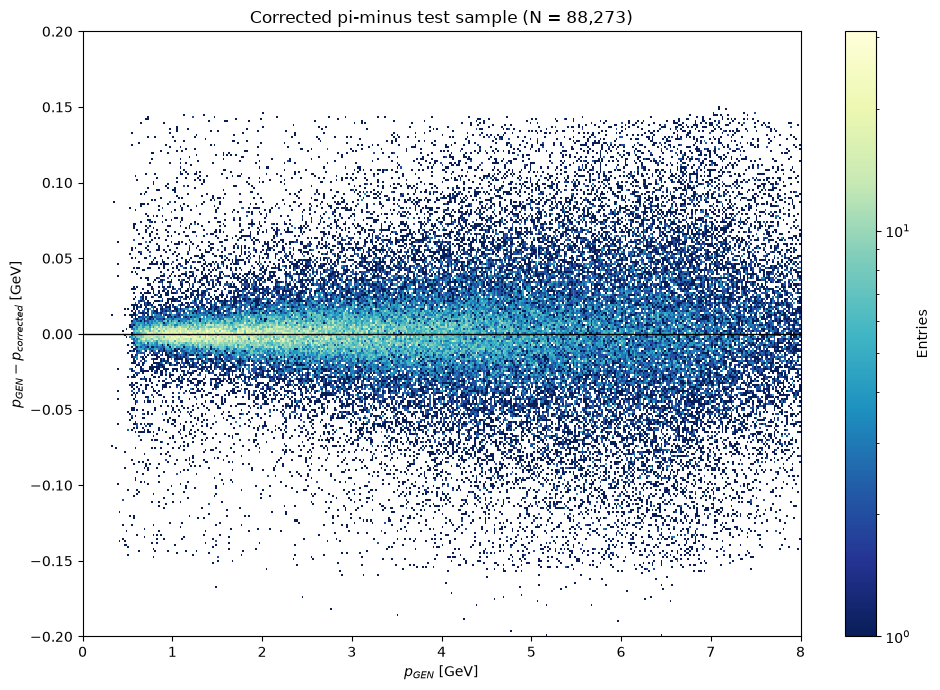

In [54]:
# Corrected delta_p versus generated momentum for the pi-minus test sample.
p_gen_test_pi_minus = p_rec_test_pi_minus + delta_p_true_pi_minus
p_corrected_test_pi_minus = p_rec_test_pi_minus + delta_p_pred_pi_minus
delta_p_corrected_pi_minus = p_gen_test_pi_minus - p_corrected_test_pi_minus

figure, axis = plt.subplots(figsize=(10, 7), facecolor="white")
histogram = axis.hist2d(
    p_gen_test_pi_minus,
    delta_p_corrected_pi_minus,
    bins=[400, 300],
    range=[[0.0, 8.0], [-0.2, 0.2]],
    norm=LogNorm(),
    cmap="YlGnBu_r",
)
axis.axhline(0.0, color="black", linewidth=1.0)
axis.set_xlabel(r"$p_{GEN}$ [GeV]")
axis.set_ylabel(r"$p_{GEN} - p_{corrected}$ [GeV]")
axis.set_title(f"Corrected pi-minus test sample (N = {len(p_gen_test_pi_minus):,})")
figure.colorbar(histogram[3], ax=axis, label="Entries")
figure.tight_layout()
plt.show()

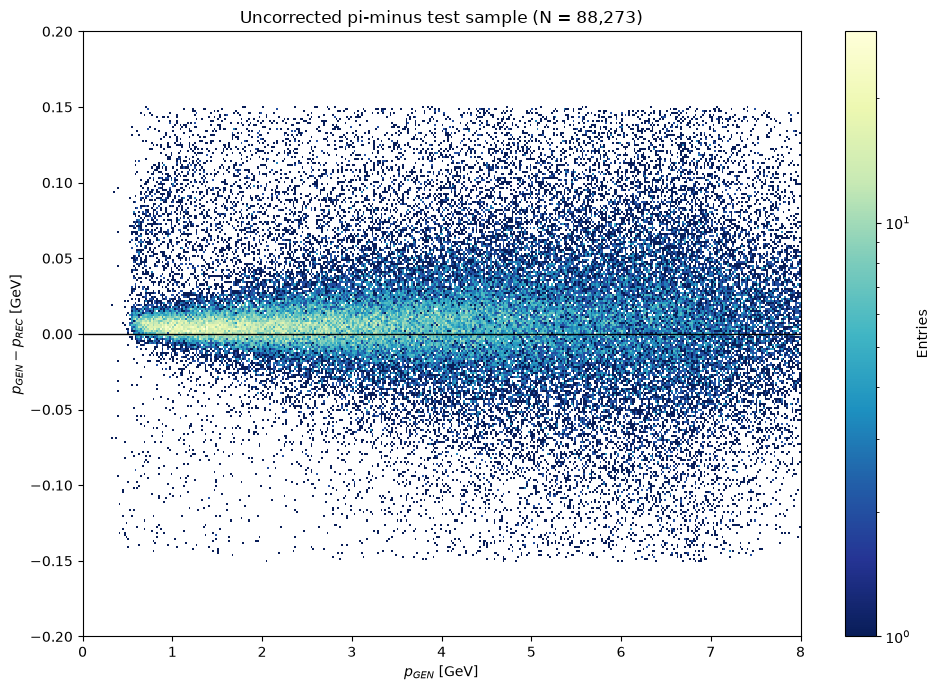

In [55]:
# Uncorrected delta_p versus generated momentum for the pi-minus test sample.
delta_p_uncorrected_pi_minus = p_gen_test_pi_minus - p_rec_test_pi_minus

figure, axis = plt.subplots(figsize=(10, 7), facecolor="white")
histogram = axis.hist2d(
    p_gen_test_pi_minus,
    delta_p_uncorrected_pi_minus,
    bins=[400, 300],
    range=[[0.0, 8.0], [-0.2, 0.2]],
    norm=LogNorm(),
    cmap="YlGnBu_r",
)
axis.axhline(0.0, color="black", linewidth=1.0)
axis.set_xlabel(r"$p_{GEN}$ [GeV]")
axis.set_ylabel(r"$p_{GEN} - p_{REC}$ [GeV]")
axis.set_title(f"Uncorrected pi-minus test sample (N = {len(p_gen_test_pi_minus):,})")
figure.colorbar(histogram[3], ax=axis, label="Entries")
figure.tight_layout()
plt.show()